# Sensitivity analysis: which scaling groups matter, and how cleanly

To decide which of the model's 18 kinetic scaling groups are worth spending inference
budget on, we ran a Morris elementary-effects screen (`morris_screen.py`) over all 14
chain-length systems: radial design, Latin hypercube base points, `r=200` trajectories
per system, each scaling group varied independently over a 100-fold window centered on
its nominal value (log10-uniform -- the same window a1's own prior uses).

This is a different question from the PNAS screen this model comes from: Ruppe et al.
2020 varied *enzyme concentrations* and found FabF/TesA dominate chain length. This
screen varies *kinetic scaling groups* instead, which answers "which parameter is worth
inferring" rather than "which enzyme should an engineer titrate."

Two numbers come out of every screen:

- **mu\*** -- mean |elementary effect|, i.e. overall influence. Normalized to each
  system's own top-ranked group before pooling (raw units differ system to system).
  Used to rank groups.
- **sigma/mu\*** -- how much a group's effect depends on where the *other* parameters
  currently sit. Already a dimensionless ratio, no normalization needed. A diagonal
  mass matrix (the sampler's default) can't represent correlation between parameters,
  so a high-sigma/mu\* group is a warning sign for joint inference, not just a
  one-at-a-time-sweep caveat.

In [1]:
import glob
import json
import re
from statistics import median
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams.update({"font.size": 13})

OBJECTIVES = ["total_production", "avg_chain_length", "unsat_fraction"]
OBJ_LABEL = {"total_production": "Total production",
            "avg_chain_length": "Average chain length",
            "unsat_fraction": "Unsaturated fraction"}
SHORT_NAME = {"total_production": "Yield", "avg_chain_length": "AvgChn", "unsat_fraction": "Unsat"}

# Reactions after template expansion (build_ode_system_from_reactions).
N_REACTIONS = {
    "C4_NoFB": 56, "C6": 121, "C8": 160, "C10": 199, "C12": 238,
    "C12+unsat": 274, "C14": 277, "C14+unsat": 352, "C16": 316,
    "C16+unsat": 430, "C18": 355, "C18+unsat": 508, "C20": 394,
    "C20+unsat": 586,
}

def system_name(path):
    stem = path.split("/")[-1][len("morris_"):-len(".json")]
    return re.sub(r"_unsat$", "+unsat", stem)

def chain_key(name):
    m = re.match(r"C(\d+)", name)
    return (int(m.group(1)) if m else 999, "+unsat" in name, name)

def _chain_len(s):
    m = re.match(r"C(\d+)", s)
    return int(m.group(1)) if m else 999

def three_way_split(systems_here):
    """C4-C10 never has an unsaturated option at all, so it's kept separate
    rather than lumped into "saturated" -- that leaves the other two as a
    matched, same-chain-length-range sat/unsat comparison."""
    small = [s for s in systems_here if _chain_len(s) <= 10]
    sat = [s for s in systems_here if _chain_len(s) >= 12 and "+unsat" not in s]
    unsat = [s for s in systems_here if _chain_len(s) >= 12 and "+unsat" in s]
    return small, sat, unsat

DATA = {}
for path in sorted(glob.glob("morris_*.json")):
    d = json.load(open(path))
    DATA[system_name(path)] = d

systems = sorted(DATA, key=chain_key)
print(f"{len(systems)} systems loaded: {systems}")

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sys_color = {s: default_colors[i % len(default_colors)] for i, s in enumerate(systems)}
full_cmap = plt.get_cmap("tab20")
# Fixed group -> color, independent of any one objective's own alphabetical
# `order` (a group's position there can shift slightly across objectives).
ALL_GROUPS = sorted({r["group"] for s in systems for res in DATA[s]["results"].values() for r in res})
group_color = {g: full_cmap(i % 20) for i, g in enumerate(ALL_GROUPS)}

# Enzymatic/functional category per scaling group, per the user's own final
# domain assignment (not every group's full enzyme footprint matches its
# category exactly -- e.g. c1 touches only FabH). b1, b2, b3, e, f, x1-x4 are
# deliberately left uncategorized (uncolored) per that same call.
STAGE_COLOR = {"initiation": "#cfe2f3", "elongation": "#d9ead3", "termination": "#fce5cd"}
GROUP_STAGE = {
    "a1": "initiation", "c1": "initiation",
    "a2": "elongation", "c2": "elongation",
    "a3": "termination", "c3": "termination", "d1": "termination", "d2": "termination",
}
STAGE_LINE_COLOR = {"initiation": "#1f77b4", "elongation": "#2ca02c", "termination": "#ff7f0e"}
UNCATEGORIZED_LINE_COLOR = "#7f7f7f"

14 systems loaded: ['C4_NoFB', 'C6', 'C8', 'C10', 'C12', 'C12+unsat', 'C14', 'C14+unsat', 'C16', 'C16+unsat', 'C18', 'C18+unsat', 'C20', 'C20+unsat']


In [2]:
def _category_legend_entries(order):
    """Category color swatch + name, one per category actually present in
    `order` (plus "uncategorized" if any group here has none)."""
    cats_here = [c for c in STAGE_COLOR if c in {GROUP_STAGE.get(g) for g in order}]
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=STAGE_COLOR[c], edgecolor="none") for c in cats_here]
    labels = list(cats_here)
    if any(GROUP_STAGE.get(g) is None for g in order):
        handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="0.6", linewidth=0.8))
        labels.append("uncategorized")
    return handles, labels


def _mark_systems(ax, systems_here, reactions):
    """Dashed reference line + name label per system, at its true reaction
    count -- overlaid on the normal numeric x-axis."""
    for s in systems_here:
        x = reactions[s]
        ax.axvline(x, color="0.75", lw=0.7, ls="--", zorder=0)
        ax.text(x, 1.01, s, transform=ax.get_xaxis_transform(), rotation=0,
                ha="center", va="bottom", fontsize=10, color="0.35")


class Metric:
    """One row of a Morris result -> one comparable number, plus the display
    conventions (ylabel/threshold line/filename/title) that go with it."""
    def __init__(self, key, ylabel, title_word, file_word, threshold=None):
        self.key, self.ylabel, self.title_word, self.file_word, self.threshold = (
            key, ylabel, title_word, file_word, threshold)

    def table(self, obj):
        """{group: {system: value}}"""
        per_group = {}
        for s in systems:
            res = DATA[s]["results"].get(obj)
            if not res:
                continue
            if self.key == "mu_star":
                top = max(r["mu_star"] for r in res)
                if top <= 0:
                    continue
                for r in res:
                    per_group.setdefault(r["group"], {})[s] = 100.0 * r["mu_star"] / top
            else:
                for r in res:
                    if r["mu_star"] > 0:
                        per_group.setdefault(r["group"], {})[s] = r["sigma"] / r["mu_star"]
        return per_group


MU_STAR = Metric("mu_star", "Normalized mu*", "Sensitivity Analysis", "", threshold=None)
INTERACTION = Metric("interaction", "sigma / mu*", "Interaction Ratio", "_Interaction", threshold=1.0)


def _threshold_line(ax, metric):
    if metric.threshold is not None:
        ax.axhline(metric.threshold, color="0.4", lw=0.8, ls=":", zorder=1)


def bar_chart_figures(metric):
    """Grouped bar chart per objective: scaling group on the x-axis, one bar
    per system, split 3 ways (C4-C10 / C12-C20 saturated / C12-C20
    unsaturated), plus a 4th panel pooling every system (median bar + each
    system's own value as a dot)."""
    for obj in OBJECTIVES:
        per_group = metric.table(obj)
        if not per_group:
            continue
        order = sorted(per_group)
        systems_here = sorted([s for s in systems if any(s in per_group[g] for g in order)],
                              key=lambda s: N_REACTIONS[s])
        n_groups = len(order)
        small_systems, sat_systems, unsat_systems = three_way_split(systems_here)

        candidates = [(small_systems, "C4-C10"), (sat_systems, "C12-C20 (saturated)"),
                     (unsat_systems, "C12-C20 (unsaturated)")]
        bar_panels_data = [(subset, title) for subset, title in candidates if subset]
        n_bar_rows = len(bar_panels_data) + 1
        fig, axes = plt.subplots(n_bar_rows, 1,
                                 figsize=(max(10, 0.62 * n_groups), 5.5 * n_bar_rows),
                                 sharey=True, squeeze=False)
        axes = axes[:, 0]
        extra_artists = []
        for ax, (subset, subtitle) in zip(axes, bar_panels_data):
            for gi, g in enumerate(order):
                stage = GROUP_STAGE.get(g)
                if stage:
                    ax.axvspan(gi - 0.5, gi + 0.5, color=STAGE_COLOR[stage], zorder=0)
            bw = 0.8 / len(subset)
            for gi, g in enumerate(order):
                vals = per_group[g]
                for si, s in enumerate(subset):
                    if s not in vals:
                        continue
                    x = gi + (si - (len(subset) - 1) / 2) * bw
                    ax.bar(x, vals[s], width=bw * 0.95, color=sys_color[s], zorder=2)
            _threshold_line(ax, metric)
            ax.set_xticks(range(n_groups)); ax.set_xticklabels(order, rotation=0, fontsize=14)
            ax.set_title(subtitle, fontsize=14)
            ax.set_xlabel("Scaling Group", fontsize=12)
            ax.grid(alpha=.25, axis="y")
            ax.set_ylabel(metric.ylabel)
            handles = [plt.Rectangle((0, 0), 1, 1, color=sys_color[s]) for s in subset]
            labels = list(subset)
            handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="none"))
            labels.append("category")
            cat_handles, cat_labels = _category_legend_entries(order)
            handles += cat_handles
            labels += cat_labels
            legend = ax.legend(handles, labels, fontsize=10, loc="center left", bbox_to_anchor=(1.02, 0.5),
                               ncol=1, title="system", title_fontsize=11)
            extra_artists.append(legend)

        ax_all = axes[-1]
        for gi, g in enumerate(order):
            stage = GROUP_STAGE.get(g)
            if stage:
                ax_all.axvspan(gi - 0.5, gi + 0.5, color=STAGE_COLOR[stage], zorder=0)
        for gi, g in enumerate(order):
            vals = per_group[g]
            if not vals:
                continue
            ax_all.bar(gi, median(vals.values()), width=0.6, color="0.6", zorder=2)
            present = [s for s in systems if s in vals]
            n = len(present)
            for si, s in enumerate(present):
                x = gi + (si - (n - 1) / 2) * (0.5 / n)
                ax_all.scatter(x, vals[s], color=sys_color[s], edgecolor="black",
                               linewidth=0.4, s=25, zorder=3)
        _threshold_line(ax_all, metric)
        ax_all.set_xticks(range(n_groups)); ax_all.set_xticklabels(order, rotation=0, fontsize=14)
        ax_all.set_title("All Systems (median + individual chains)", fontsize=14)
        ax_all.set_xlabel("Scaling Group", fontsize=12)
        ax_all.grid(alpha=.25, axis="y")
        ax_all.set_ylabel(metric.ylabel)
        median_handle = plt.Rectangle((0, 0), 1, 1, color="0.6")
        dot_handle = plt.Line2D([0], [0], marker="o", linestyle="None", markersize=6,
                                markerfacecolor="0.4", markeredgecolor="black")
        handles = [median_handle, dot_handle]
        labels = ["median", "individual chain"]
        handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="none"))
        labels.append("category")
        cat_handles, cat_labels = _category_legend_entries(order)
        handles += cat_handles
        labels += cat_labels
        legend = ax_all.legend(handles, labels, fontsize=10, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1)
        extra_artists.append(legend)

        fig.suptitle(f"{metric.title_word} - {OBJ_LABEL[obj]}", fontsize=18, y=1.005)
        plt.tight_layout()
        plt.savefig(f"SensitivityAnalysis_{SHORT_NAME[obj]}_BarPlot{metric.file_word}.png", dpi=130,
                   bbox_inches="tight", bbox_extra_artists=extra_artists)
        plt.show()


def line_trend_figures(metric):
    """Line-trend per objective: reactions in the solved system on the
    x-axis, one line per scaling group, split Saturated (C4-C20 combined) /
    Unsaturated. Two rows of the same data -- top colored per-parameter,
    bottom recolored per-category -- so a shared category shows up as
    matching line colors in the bottom row."""
    for obj in OBJECTIVES:
        per_group = metric.table(obj)
        if not per_group:
            continue
        order = sorted(per_group)
        systems_here = sorted([s for s in systems if any(s in per_group[g] for g in order)],
                              key=lambda s: N_REACTIONS[s])
        small_systems, sat_systems, unsat_systems = three_way_split(systems_here)

        trend_candidates = [(small_systems + sat_systems, "Saturated"), (unsat_systems, "Unsaturated")]
        trend_panels_data = [(subset, title) for subset, title in trend_candidates if subset]
        ncols = len(trend_panels_data)
        width_ratios = [2 if title == "Saturated" else 1 for _, title in trend_panels_data]
        fig = plt.figure(figsize=(20 * sum(width_ratios) / 3, 17))
        gs = fig.add_gridspec(nrows=6, ncols=ncols, width_ratios=width_ratios,
                              height_ratios=[1.3, 4, 0.9, 1.3, 4, 0.9],
                              hspace=0.4, wspace=0.15, top=0.95, bottom=0.03, left=0.06, right=0.98)
        bottoms, tops, _, _ = gs.get_grid_positions(fig)

        axes_top, axes_bot = [], []
        share_ax = None
        for col in range(ncols):
            ax = fig.add_subplot(gs[1, col], sharey=share_ax)
            share_ax = share_ax or ax
            axes_top.append(ax)
        for col in range(ncols):
            axes_bot.append(fig.add_subplot(gs[4, col], sharey=share_ax))

        for col, (subset, subtitle) in enumerate(trend_panels_data):
            ax_top, ax_bot = axes_top[col], axes_bot[col]
            for gi, g in enumerate(order):
                xs, ys = [], []
                for s in subset:
                    if s in per_group[g]:
                        xs.append(N_REACTIONS[s]); ys.append(per_group[g][s])
                if not xs:
                    continue
                ax_top.plot(xs, ys, "o-", ms=4, lw=1.5, color=group_color[g], label=g)
                cat_color = STAGE_LINE_COLOR.get(GROUP_STAGE.get(g), UNCATEGORIZED_LINE_COLOR)
                ax_bot.plot(xs, ys, "o-", ms=4, lw=1.5, color=cat_color, label=g)
            for ax in (ax_top, ax_bot):
                _threshold_line(ax, metric)
                ax.set_xlabel("Number of Reactions")
                _mark_systems(ax, subset, N_REACTIONS)
                ax.grid(alpha=.25, which="both")
            ax_top.set_title(subtitle, fontsize=14, y=1.06)
            ax_bot.set_title(subtitle, fontsize=14, y=1.06)
        axes_top[0].set_ylabel(metric.ylabel)
        axes_bot[0].set_ylabel(metric.ylabel)

        fig.text(0.5, tops[0], "Colored by Parameter", ha="center", va="top", fontsize=16)
        fig.text(0.5, tops[3], "Colored by Category", ha="center", va="top", fontsize=16)

        legend_handles = [plt.Line2D([0], [0], marker="o", ms=4, lw=1.5, color=group_color[g]) for g in order]
        fig.legend(legend_handles, order, loc="lower center", bbox_to_anchor=(0.5, bottoms[2]),
                  ncol=len(order), fontsize=15, columnspacing=1.2, handletextpad=0.5)
        cats_here = [c for c in STAGE_LINE_COLOR if c in {GROUP_STAGE.get(g) for g in order}]
        cat_handles = [plt.Line2D([0], [0], marker="o", ms=4, lw=1.5, color=STAGE_LINE_COLOR[c]) for c in cats_here]
        cat_labels = list(cats_here)
        if any(GROUP_STAGE.get(g) is None for g in order):
            cat_handles.append(plt.Line2D([0], [0], marker="o", ms=4, lw=1.5, color=UNCATEGORIZED_LINE_COLOR))
            cat_labels.append("uncategorized")
        fig.legend(cat_handles, cat_labels, loc="lower center", bbox_to_anchor=(0.5, bottoms[5]),
                  ncol=len(cat_labels), fontsize=15, columnspacing=1.2, handletextpad=0.5)
        fig.suptitle(f"{metric.title_word} - {OBJ_LABEL[obj]}", fontsize=18, y=0.985)
        plt.savefig(f"SensitivityAnalysis_{SHORT_NAME[obj]}_LinePlot{metric.file_word}.png", dpi=130, bbox_inches="tight")
        plt.show()


def combined_median_figure(metric):
    """One panel per objective, pooled across every system: the same 'All
    Systems' view from the bar charts above, stacked so all 3 objectives
    read at a glance, with an explicit chain-length legend."""
    obj_data = []
    for obj in OBJECTIVES:
        per_group = metric.table(obj)
        if per_group:
            obj_data.append((obj, per_group, sorted(per_group)))
    max_n_groups = max(len(order) for _, _, order in obj_data)

    fig, axes = plt.subplots(len(obj_data), 1,
                             figsize=(max(10, 0.62 * max_n_groups), 5.5 * len(obj_data)), squeeze=False)
    axes = axes[:, 0]
    for ax, (obj, per_group, order) in zip(axes, obj_data):
        n_groups = len(order)
        for gi, g in enumerate(order):
            stage = GROUP_STAGE.get(g)
            if stage:
                ax.axvspan(gi - 0.5, gi + 0.5, color=STAGE_COLOR[stage], zorder=0)
        for gi, g in enumerate(order):
            vals = per_group[g]
            ax.bar(gi, median(vals.values()), width=0.6, color="0.6", zorder=2)
            present = [s for s in systems if s in vals]
            n = len(present)
            for si, s in enumerate(present):
                x = gi + (si - (n - 1) / 2) * (0.5 / n)
                ax.scatter(x, vals[s], color=sys_color[s], edgecolor="black", linewidth=0.4, s=25, zorder=3)
        _threshold_line(ax, metric)
        ax.set_xticks(range(n_groups)); ax.set_xticklabels(order, rotation=0, fontsize=14)
        ax.set_title(OBJ_LABEL[obj], fontsize=14)
        ax.set_xlabel("Scaling Group", fontsize=12)
        ax.grid(alpha=.25, axis="y")
        ax.set_ylabel(metric.ylabel)

    median_handle = plt.Rectangle((0, 0), 1, 1, color="0.6")
    dot_handle = plt.Line2D([0], [0], marker="o", linestyle="None", markersize=6,
                            markerfacecolor="0.4", markeredgecolor="black")
    handles = [median_handle, dot_handle]
    labels = ["median", "individual chain"]
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="none"))
    labels.append("category")
    cat_handles, cat_labels = _category_legend_entries(ALL_GROUPS)
    handles += cat_handles
    labels += cat_labels
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="none"))
    labels.append("chain length")
    handles += [plt.Rectangle((0, 0), 1, 1, color=sys_color[s]) for s in systems]
    labels += list(systems)
    legend = fig.legend(handles, labels, fontsize=10, loc="center left", bbox_to_anchor=(1.0, 0.5), ncol=1)

    fig.suptitle(f"{metric.title_word} - All Objectives (median across chains)", fontsize=18, y=1.005)
    plt.tight_layout()
    plt.savefig(f"SensitivityAnalysis_AllObjectives_MedianPlot{metric.file_word}.png", dpi=130,
               bbox_inches="tight", bbox_extra_artists=[legend])
    plt.show()


def combined_line_trend_figures(metric):
    """Same line-trend as above, one row per objective instead of one figure
    per objective -- 2 files (parameter-colored, category-colored), since one
    figure only has room for one consistent legend across 3 stacked rows."""
    obj_trend_data = []
    for obj in OBJECTIVES:
        per_group = metric.table(obj)
        if not per_group:
            continue
        order = sorted(per_group)
        systems_here = sorted([s for s in systems if any(s in per_group[g] for g in order)],
                              key=lambda s: N_REACTIONS[s])
        small_systems, sat_systems, unsat_systems = three_way_split(systems_here)
        trend_candidates = [(small_systems + sat_systems, "Saturated"), (unsat_systems, "Unsaturated")]
        panels = [(subset, title) for subset, title in trend_candidates if subset]
        obj_trend_data.append((obj, per_group, order, panels))

    col_titles = ["Saturated", "Unsaturated"]
    trend_ncols = max(len(panels) for _, _, _, panels in obj_trend_data)
    trend_width_ratios = ([2, 1] if trend_ncols == 2 else [1] * trend_ncols)[:trend_ncols]

    def _plot(color_fn, legend_handles, legend_labels, suptitle, out_path):
        fig, axes = plt.subplots(len(obj_trend_data), trend_ncols,
                                 figsize=(20 * sum(trend_width_ratios) / 3, 6.5 * len(obj_trend_data)),
                                 sharey="row", squeeze=False,
                                 gridspec_kw={"width_ratios": trend_width_ratios})
        for row, (obj, per_group, order, panels) in enumerate(obj_trend_data):
            panels_by_title = {title: subset for subset, title in panels}
            first_visible_col = None
            for col in range(trend_ncols):
                ax = axes[row, col]
                title = col_titles[col]
                if title not in panels_by_title:
                    ax.axis("off")
                    continue
                if first_visible_col is None:
                    first_visible_col = col
                subset, subtitle = panels_by_title[title], title
                for g in order:
                    xs, ys = [], []
                    for s in subset:
                        if s in per_group[g]:
                            xs.append(N_REACTIONS[s]); ys.append(per_group[g][s])
                    if xs:
                        ax.plot(xs, ys, "o-", ms=4, lw=1.5, color=color_fn(g), label=g)
                _threshold_line(ax, metric)
                ax.set_xlabel("Number of Reactions")
                _mark_systems(ax, subset, N_REACTIONS)
                ax.grid(alpha=.25, which="both")
                if row == 0:
                    ax.set_title(subtitle, fontsize=14, y=1.06)
            vis_ax = axes[row, first_visible_col]
            vis_ax.tick_params(labelleft=True)
            vis_ax.set_ylabel(f"{OBJ_LABEL[obj]}\n{metric.ylabel}")
        fig.legend(legend_handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 1.06),
                  ncol=min(len(legend_labels), 9), fontsize=13, columnspacing=1.2, handletextpad=0.5)
        fig.suptitle(suptitle, fontsize=18, y=1.14)
        plt.tight_layout()
        plt.savefig(out_path, dpi=130, bbox_inches="tight")
        plt.show()

    param_handles = [plt.Line2D([0], [0], marker="o", ms=4, lw=1.5, color=group_color[g]) for g in ALL_GROUPS]
    _plot(lambda g: group_color[g], param_handles, ALL_GROUPS,
         f"{metric.title_word} - All Objectives (colored by parameter)",
         f"SensitivityAnalysis_AllObjectives_LinePlot_Parameter{metric.file_word}.png")

    cat_line_names = [c for c in STAGE_LINE_COLOR if any(GROUP_STAGE.get(g) == c for g in ALL_GROUPS)]
    cat_line_handles = [plt.Line2D([0], [0], marker="o", ms=4, lw=1.5, color=STAGE_LINE_COLOR[c]) for c in cat_line_names]
    if any(GROUP_STAGE.get(g) is None for g in ALL_GROUPS):
        cat_line_names = cat_line_names + ["uncategorized"]
        cat_line_handles = cat_line_handles + [plt.Line2D([0], [0], marker="o", ms=4, lw=1.5, color=UNCATEGORIZED_LINE_COLOR)]
    _plot(lambda g: STAGE_LINE_COLOR.get(GROUP_STAGE.get(g), UNCATEGORIZED_LINE_COLOR),
         cat_line_handles, cat_line_names,
         f"{metric.title_word} - All Objectives (colored by category)",
         f"SensitivityAnalysis_AllObjectives_LinePlot_Category{metric.file_word}.png")

## Overall influence: which groups actually move the observables?

To rank the 18 scaling groups by influence, we measured each group's Morris mu\*
against 3 objectives (total production, average chain length, unsaturated fraction),
normalized to that system's own top-ranked group so systems with different raw
sensitivities are comparable. Two views of the same numbers below: a bar chart per
objective (split by chain-length range) and a line-trend against reaction count,
colored both by individual parameter and by enzymatic stage (initiation / elongation
/ termination) to see whether influence tracks a group's role in the pathway.

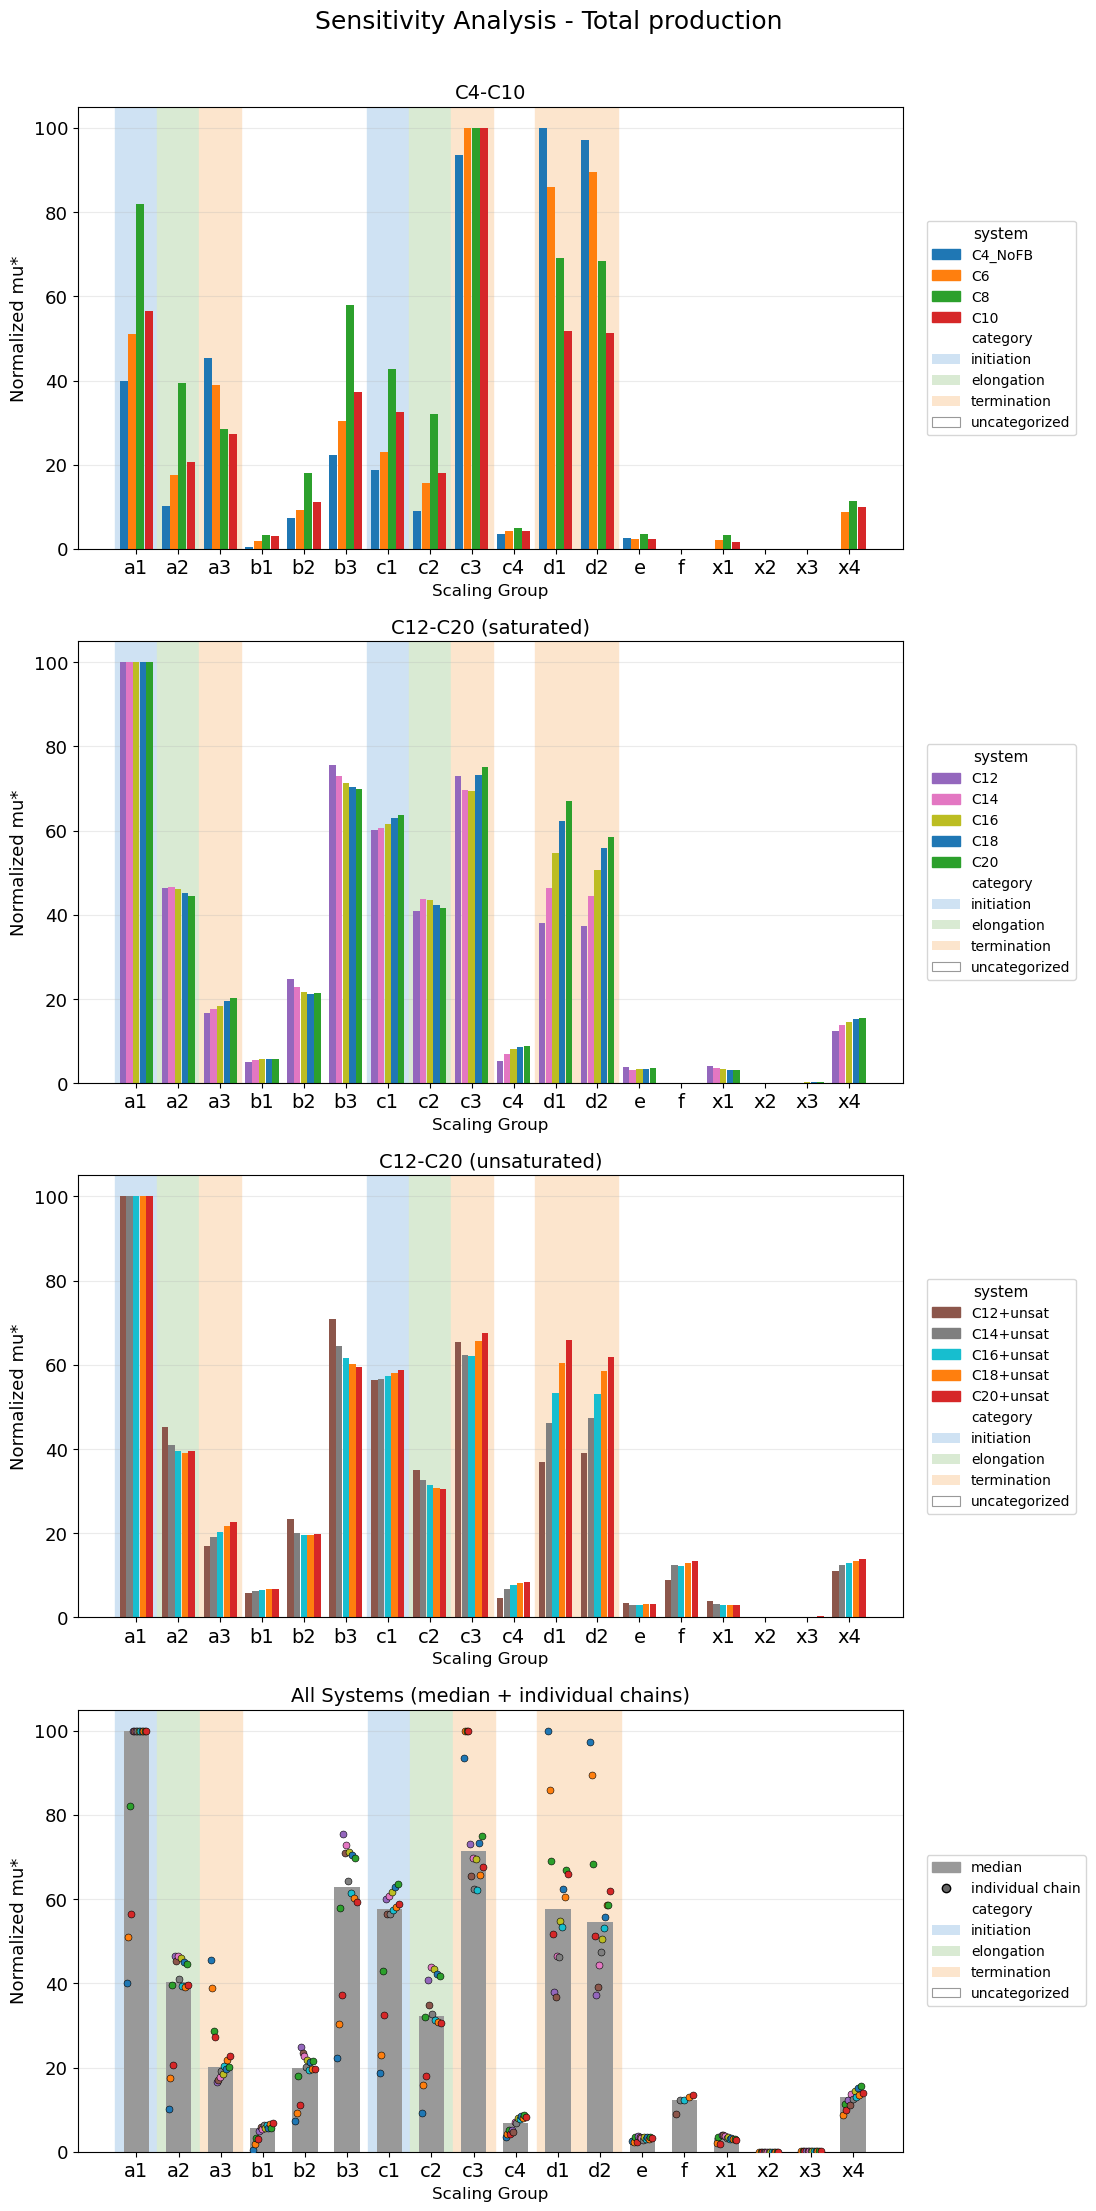

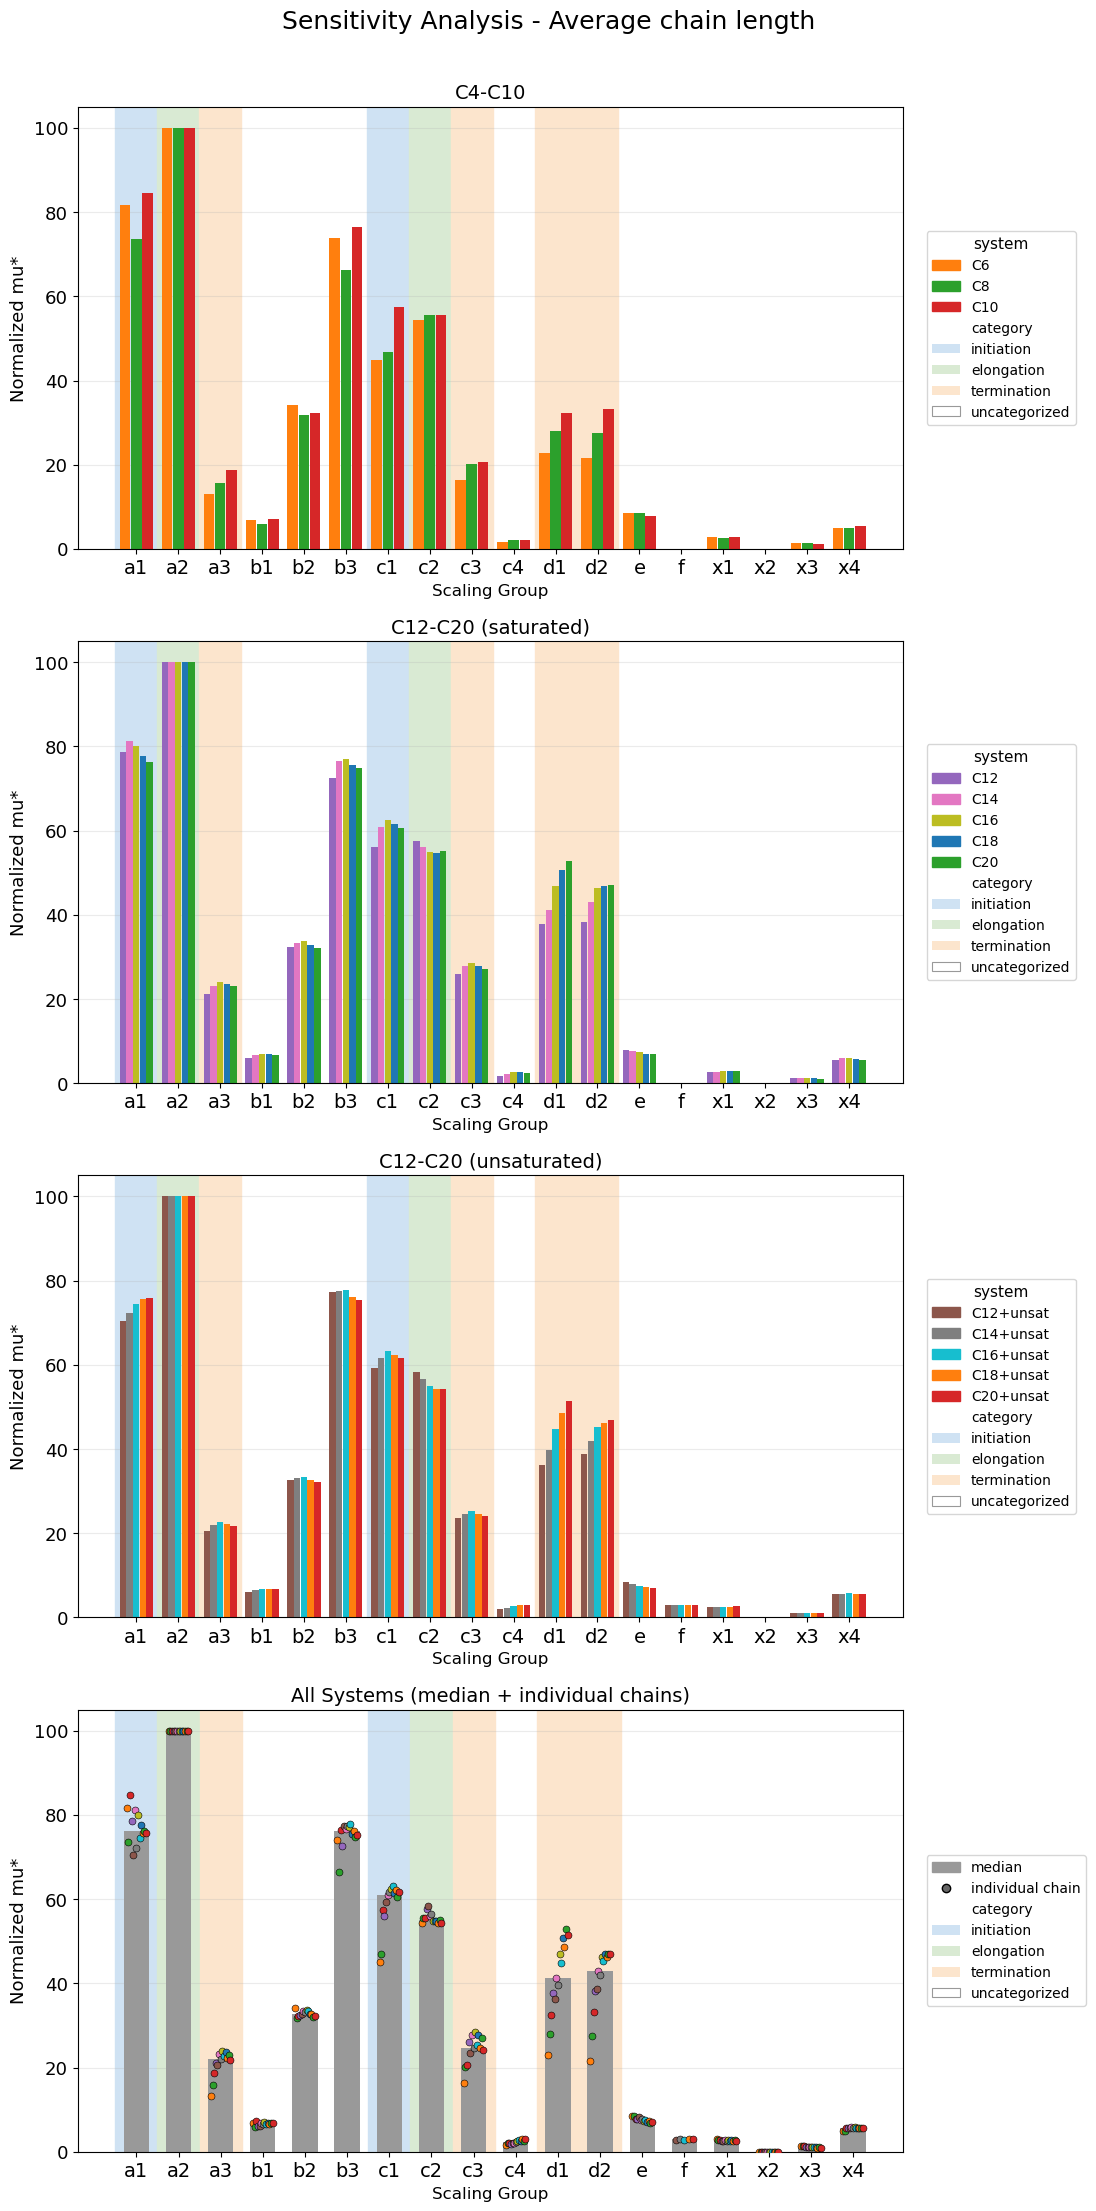

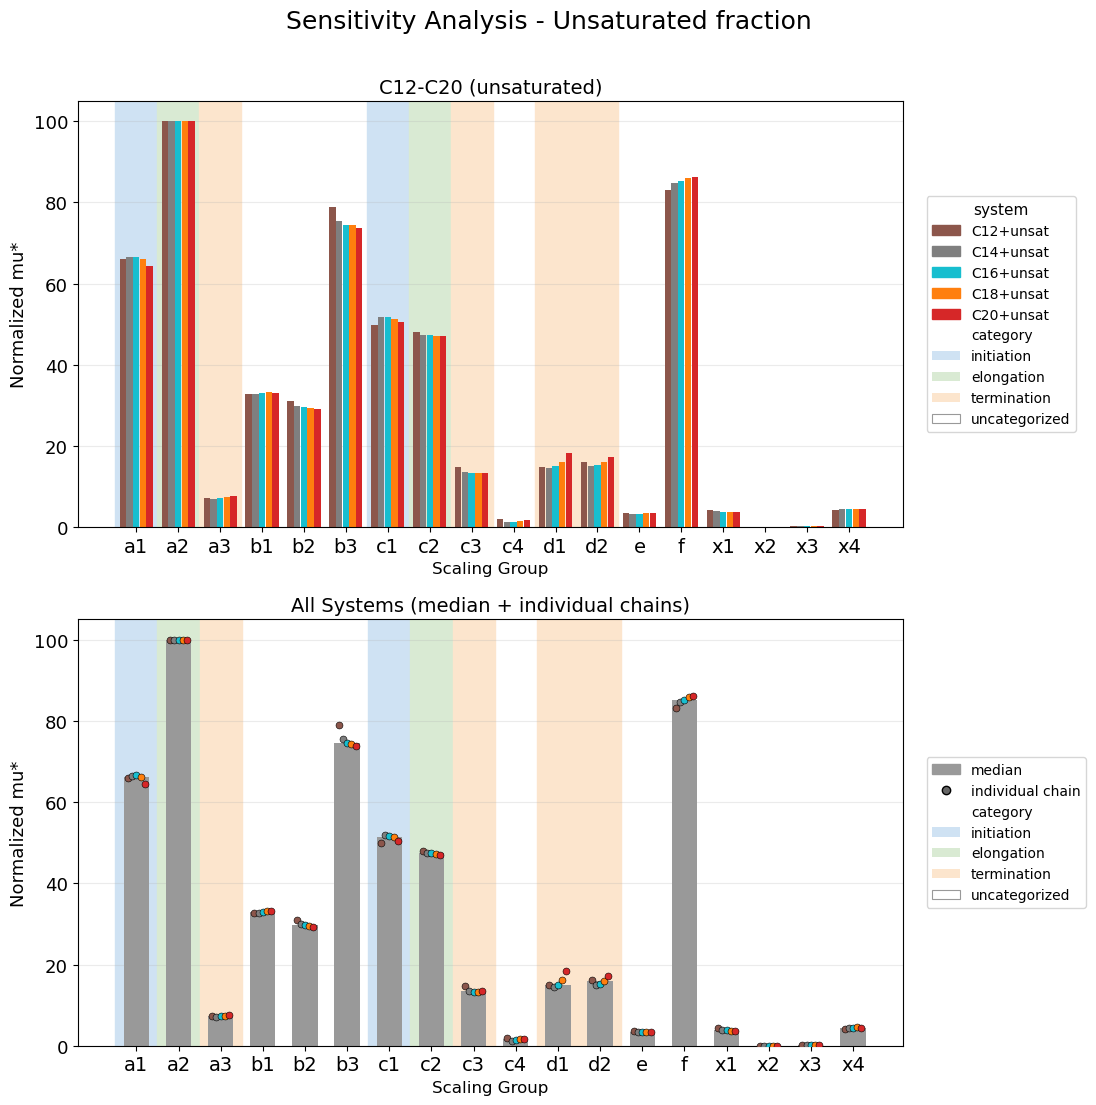

In [3]:
bar_chart_figures(MU_STAR)

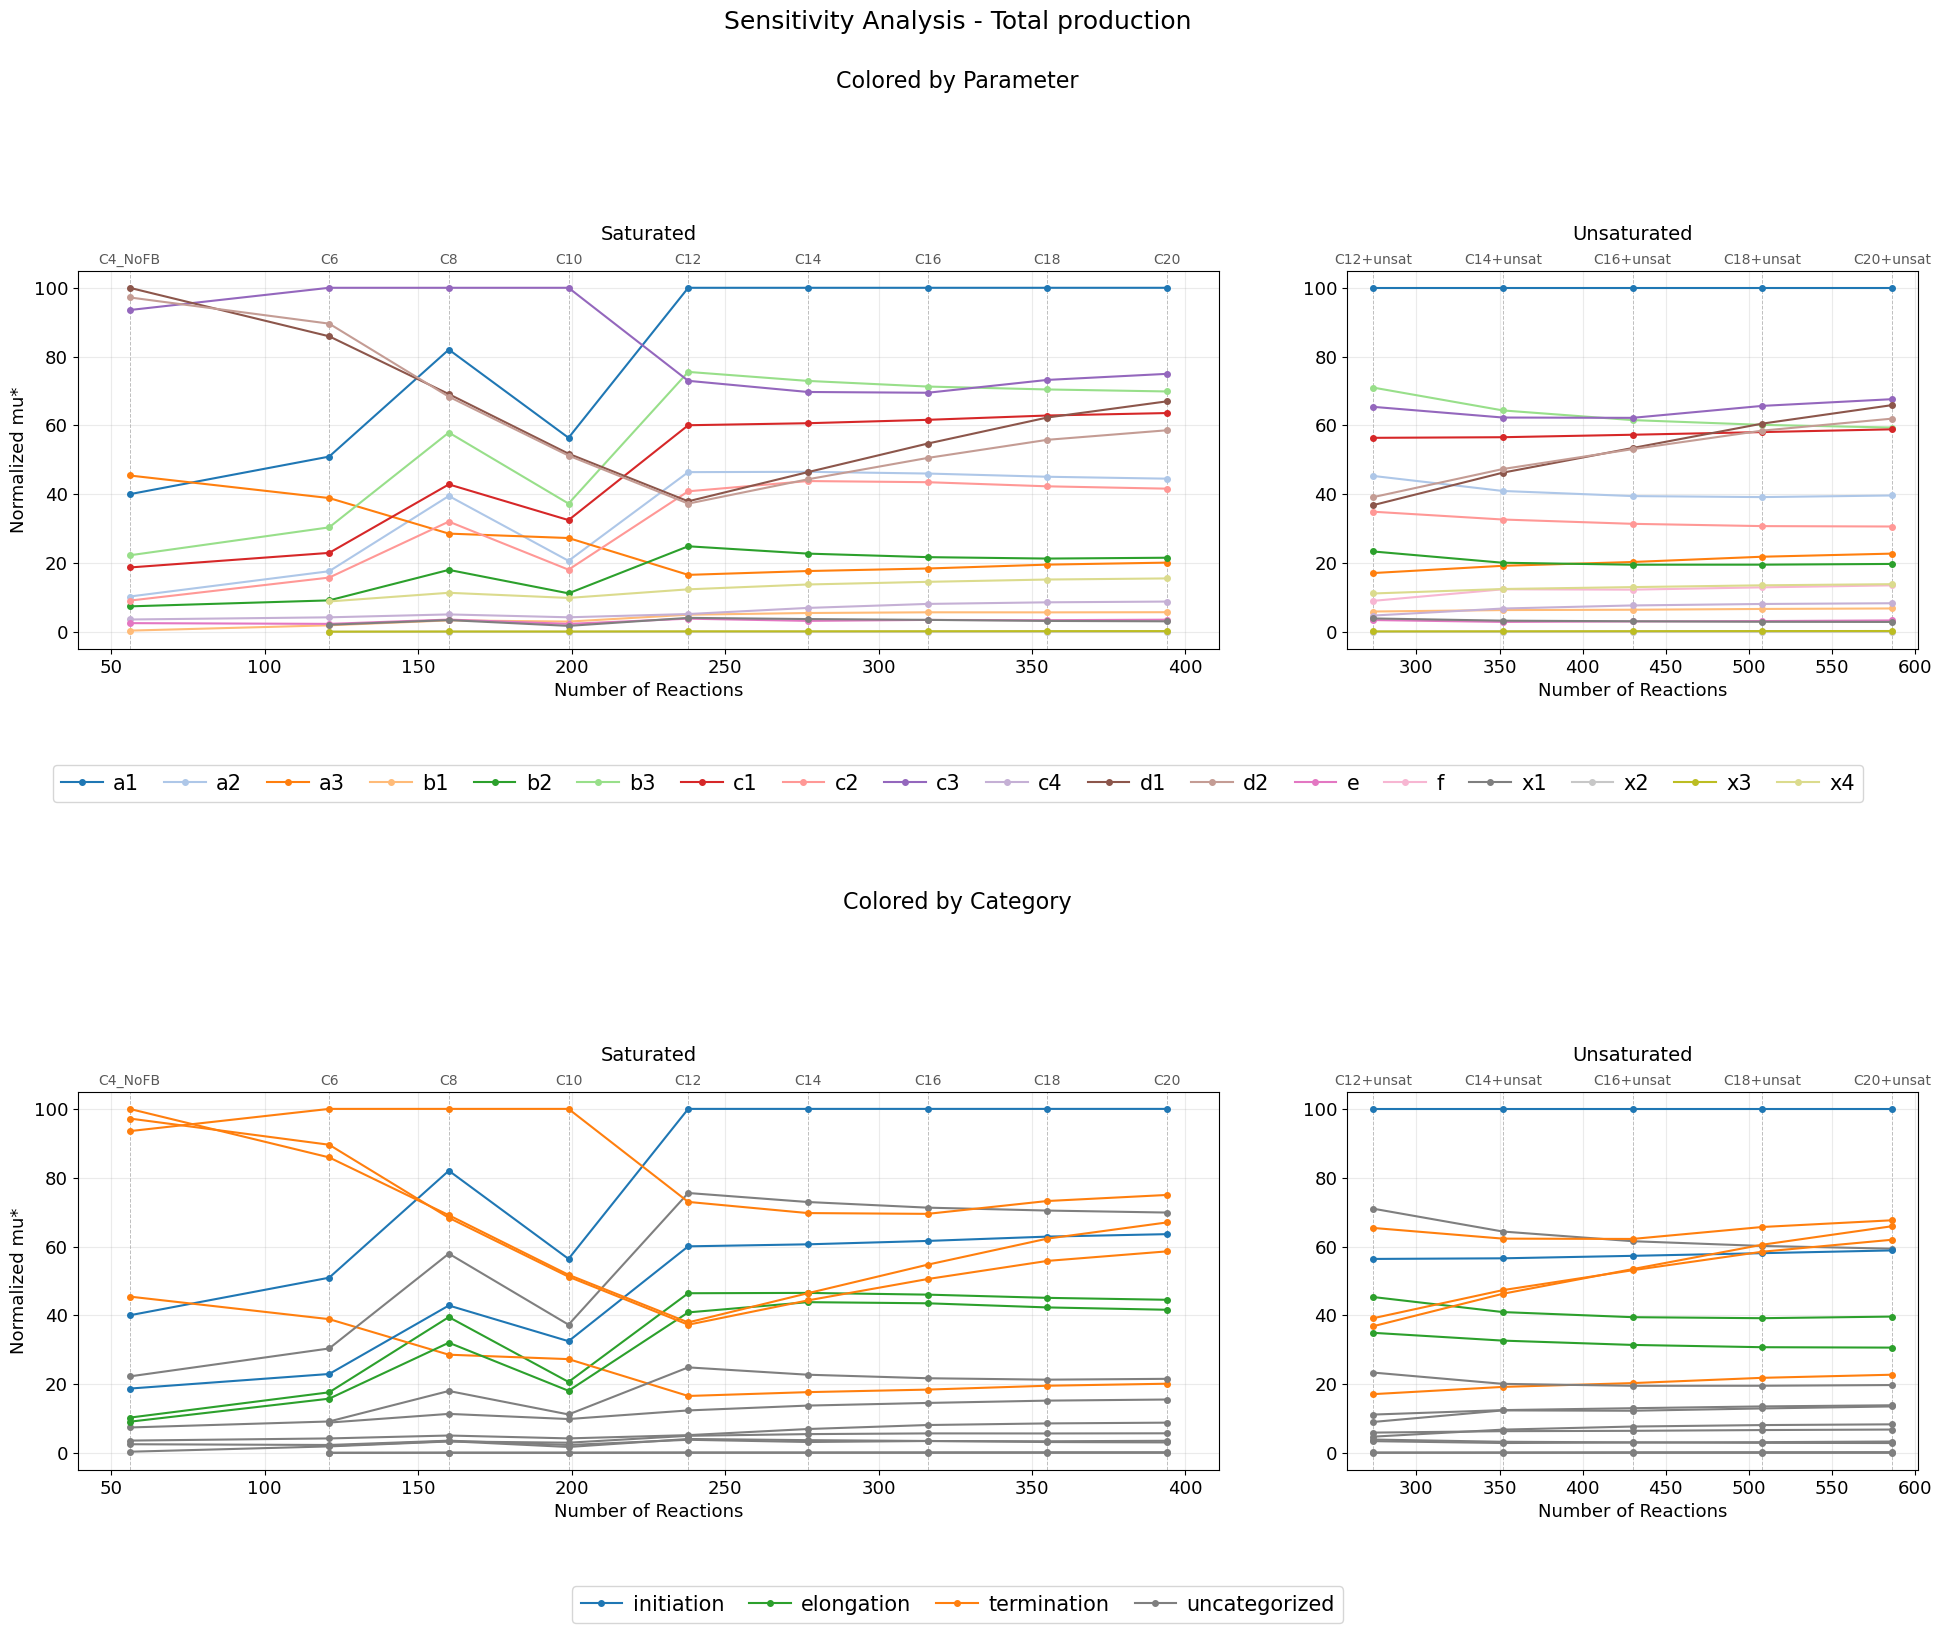

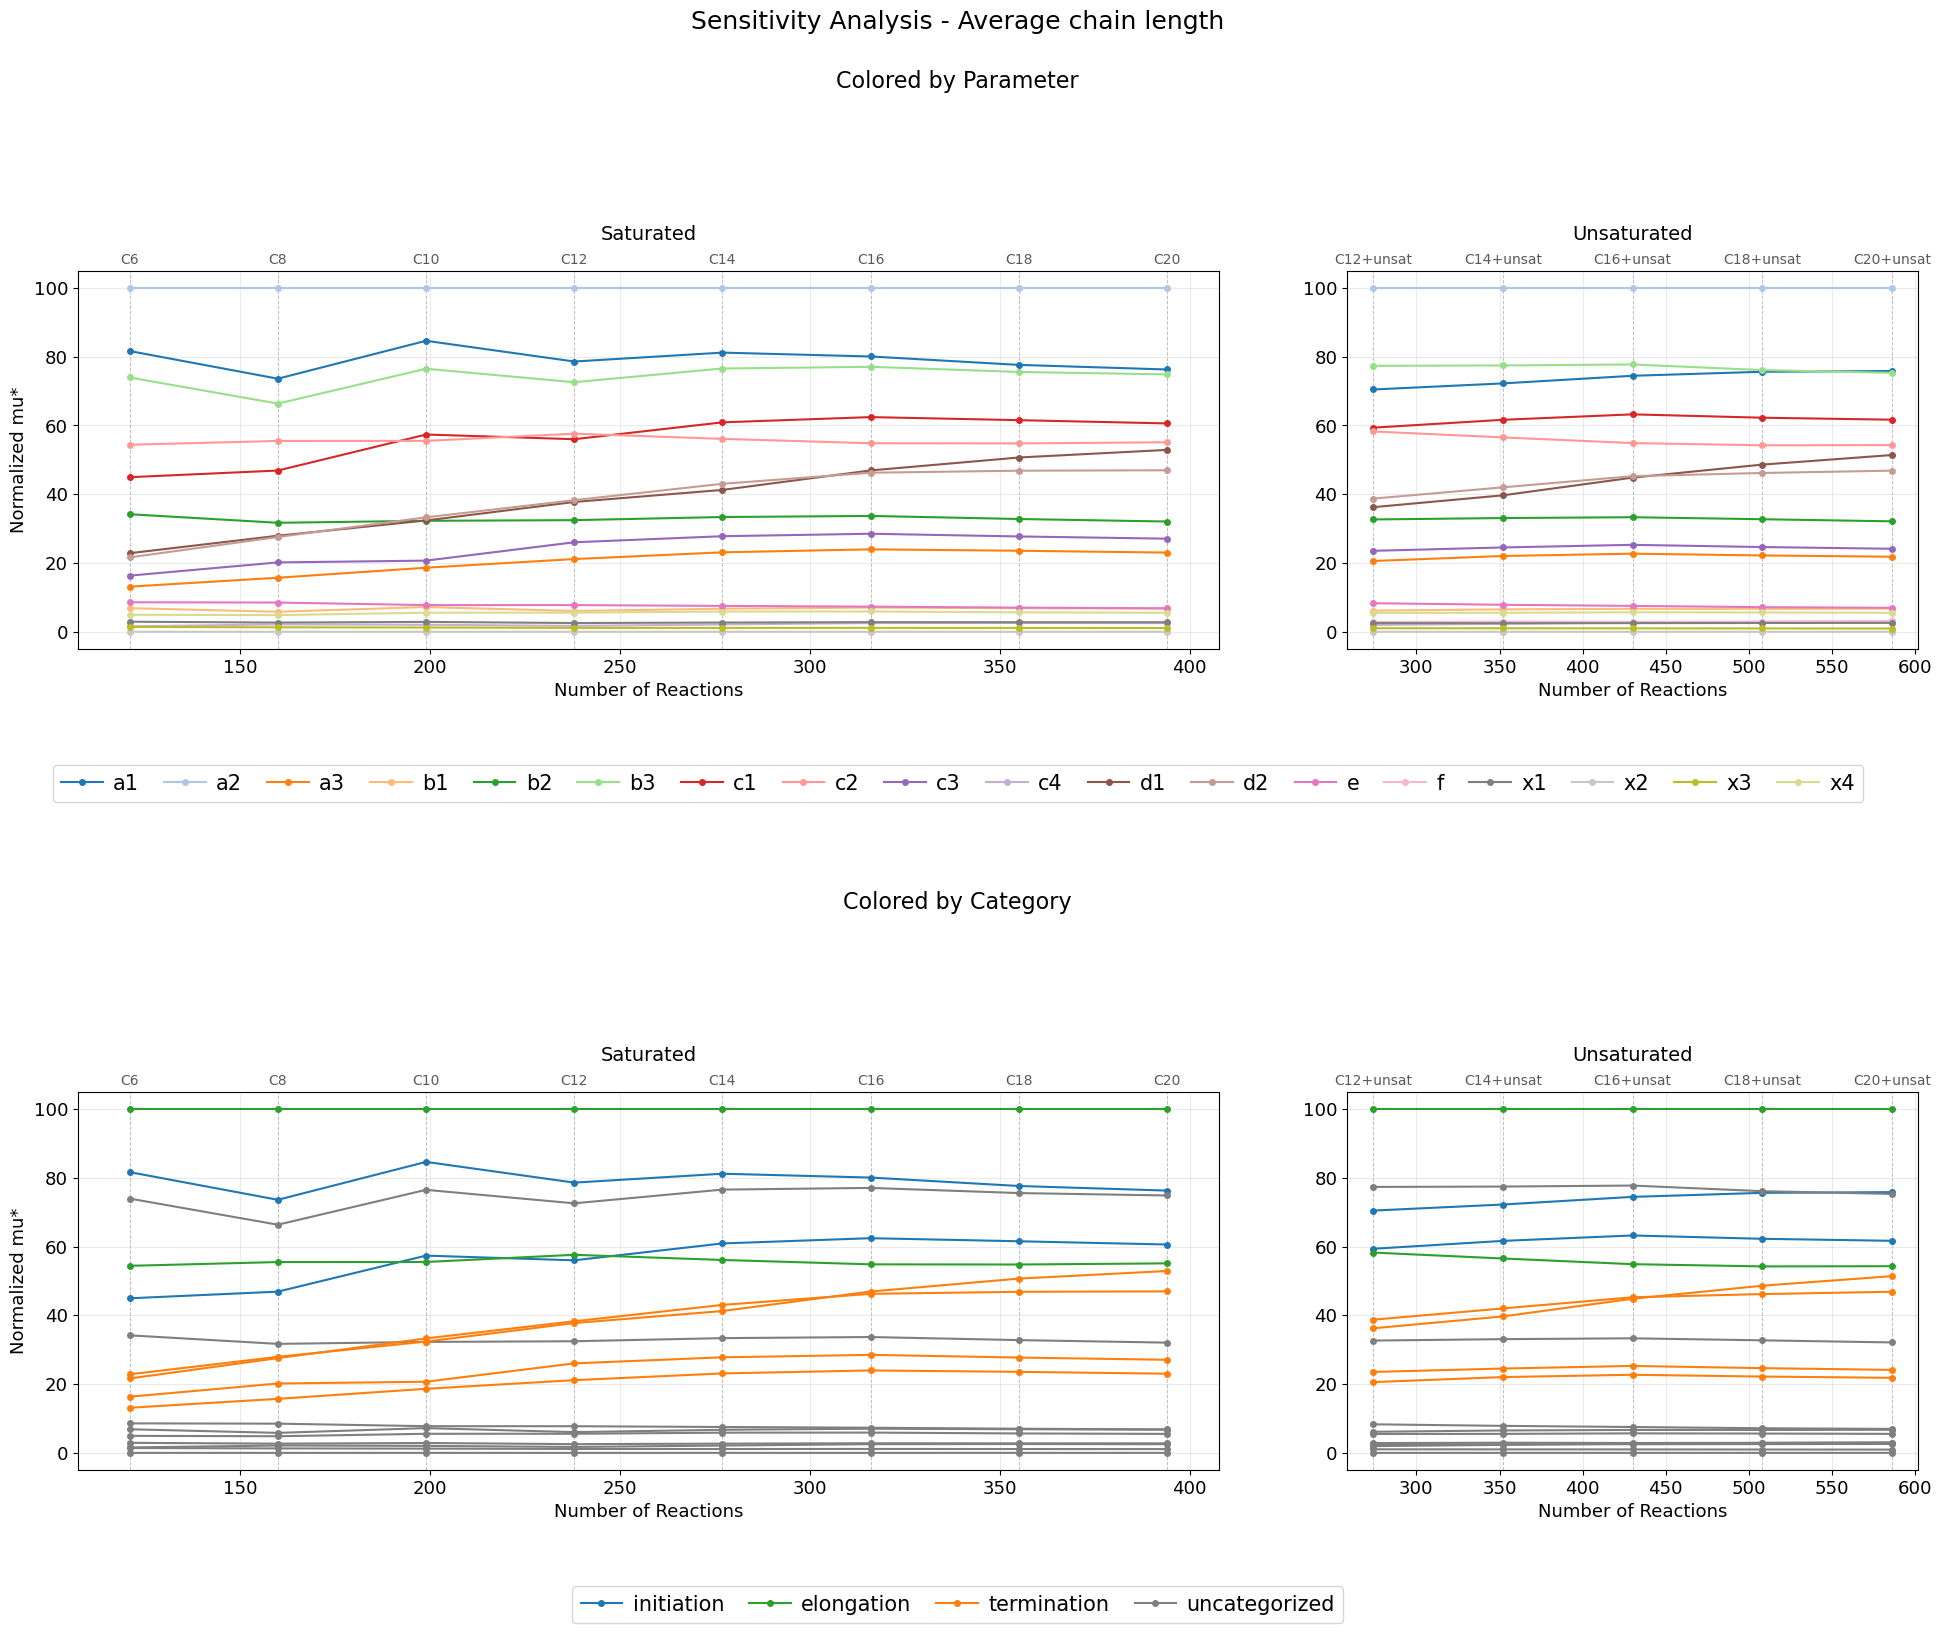

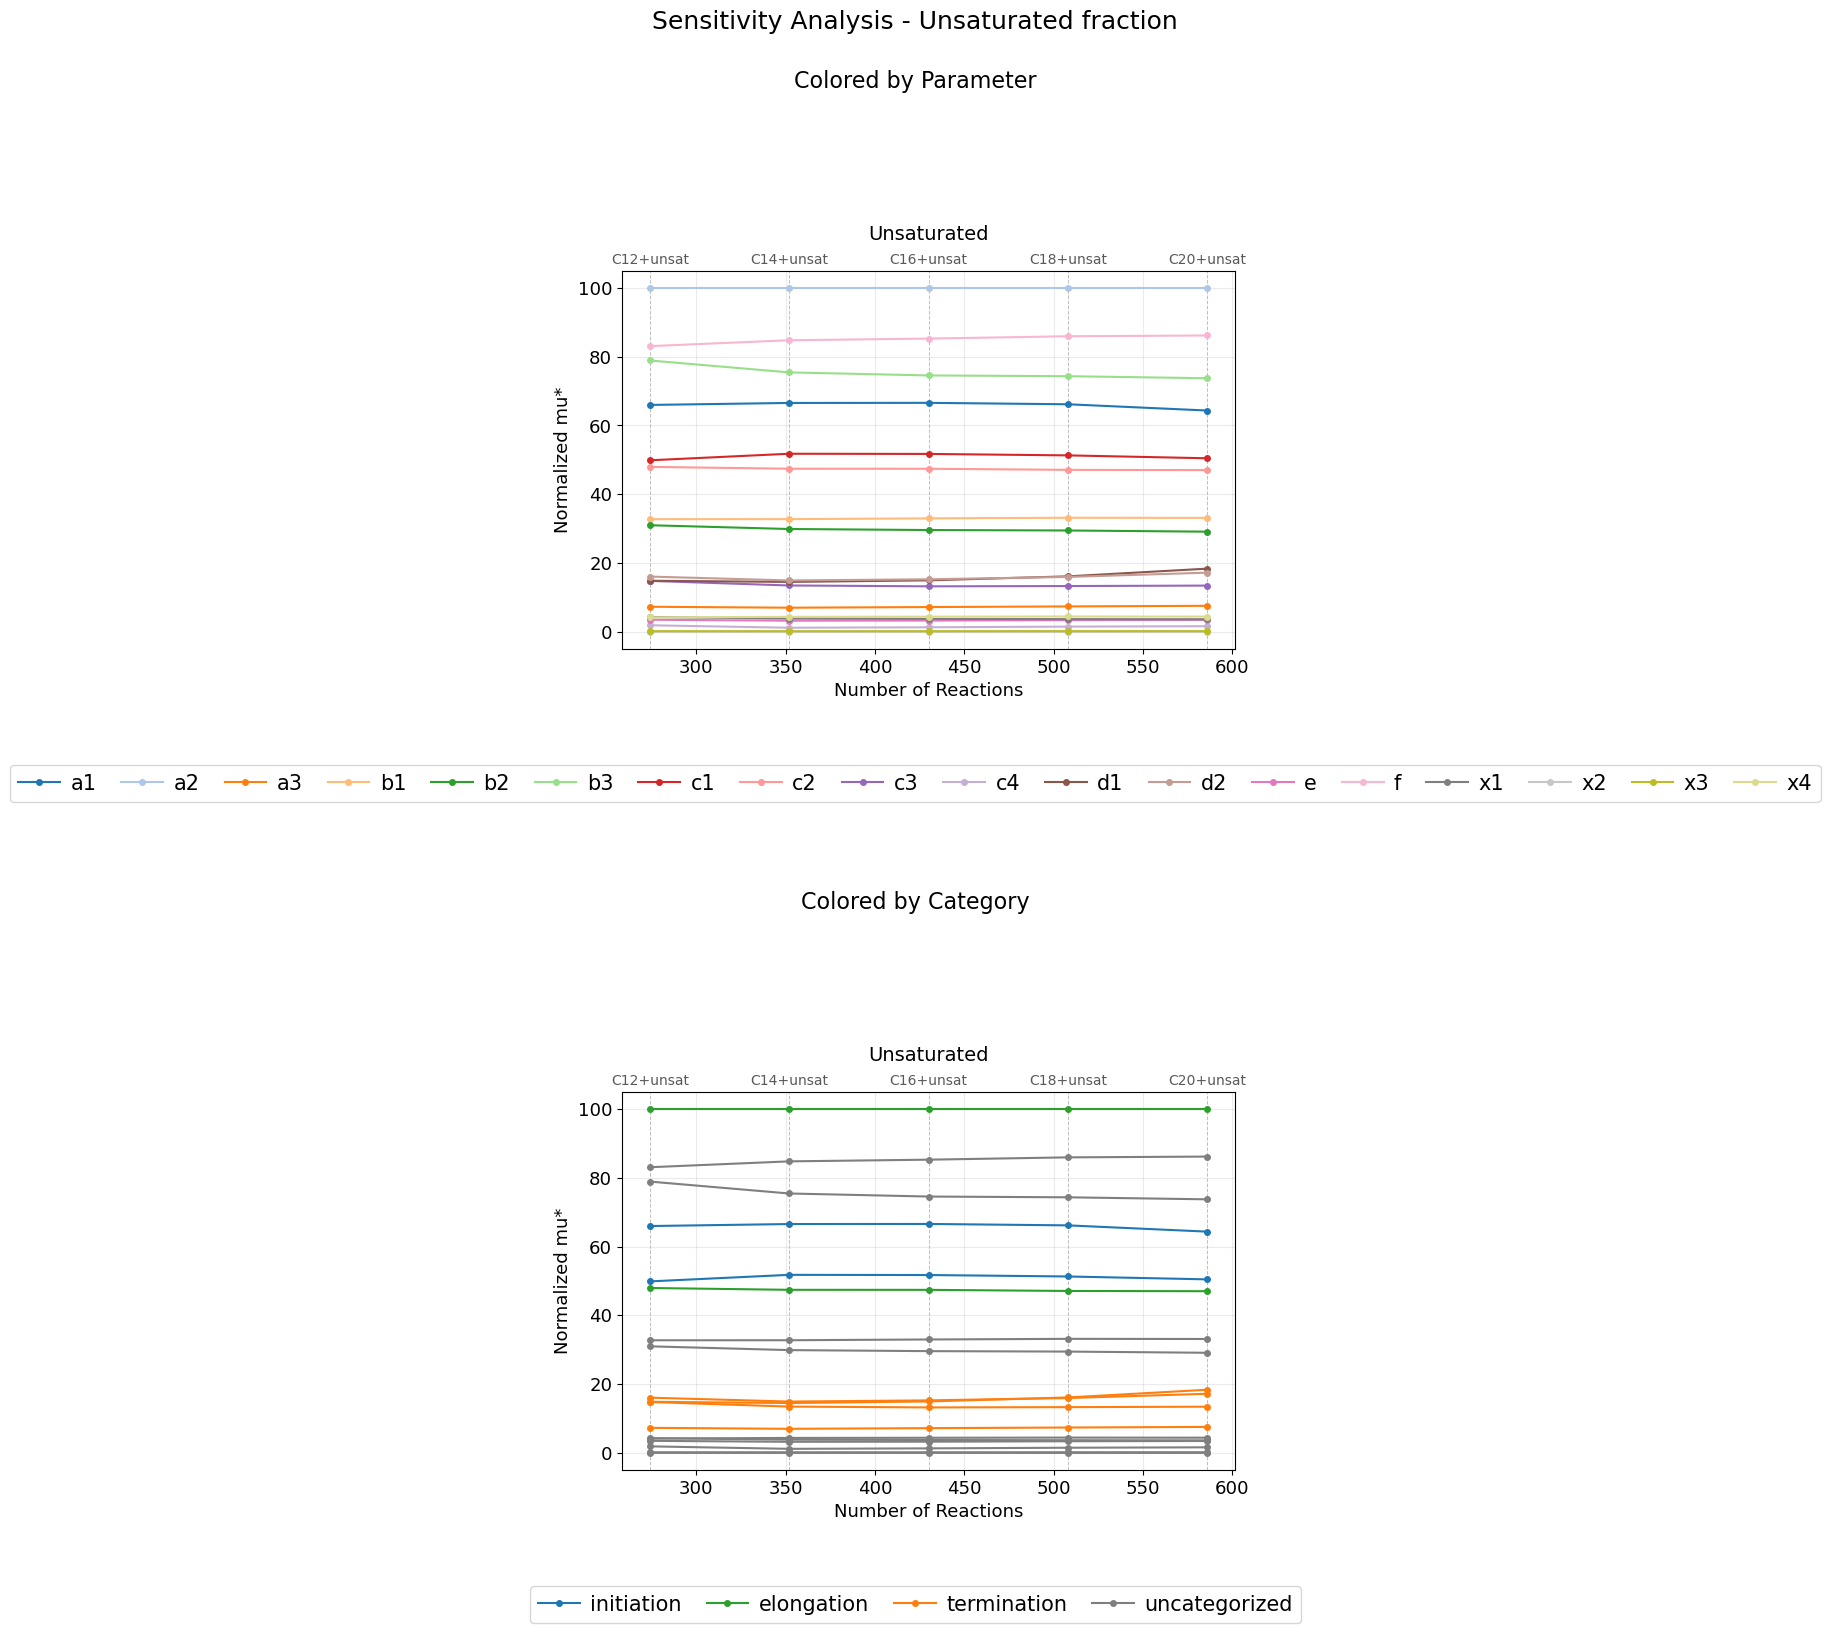

In [4]:
line_trend_figures(MU_STAR)

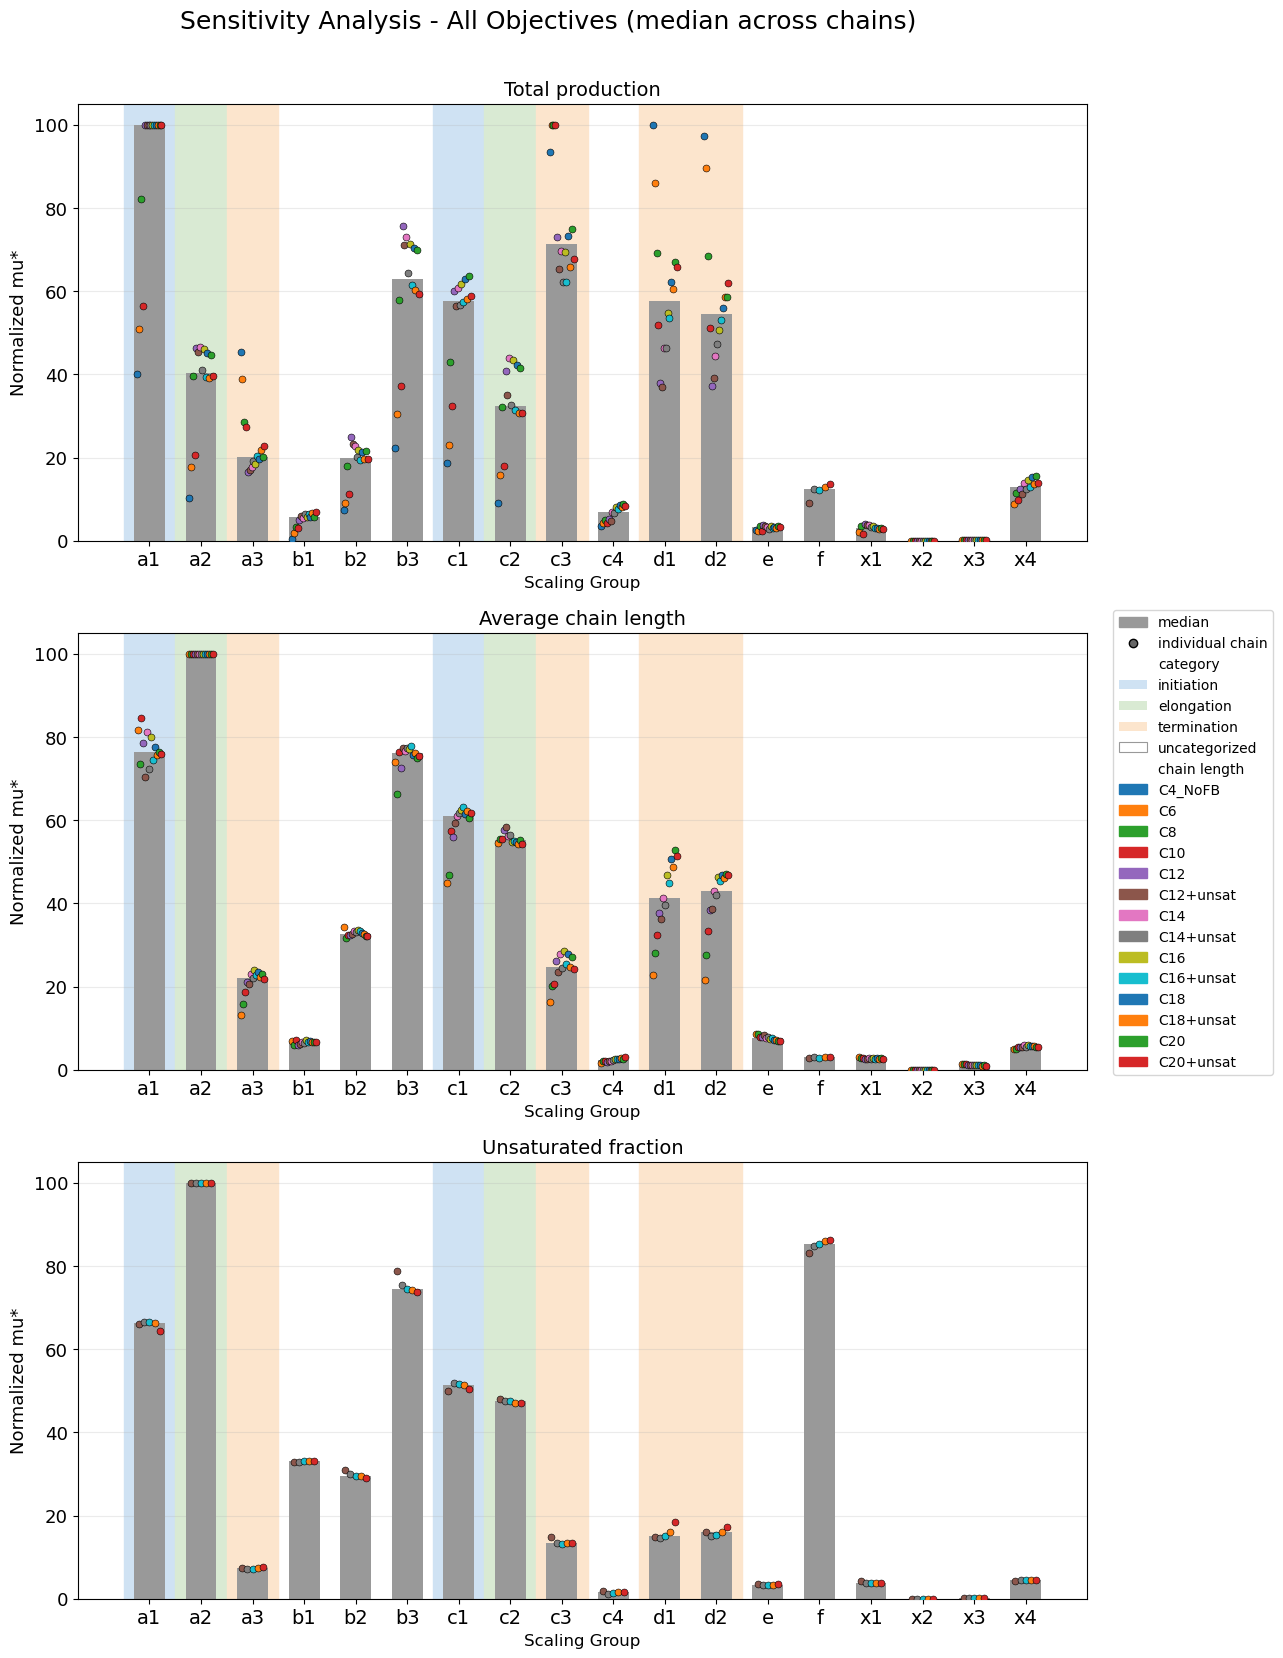

In [5]:
combined_median_figure(MU_STAR)

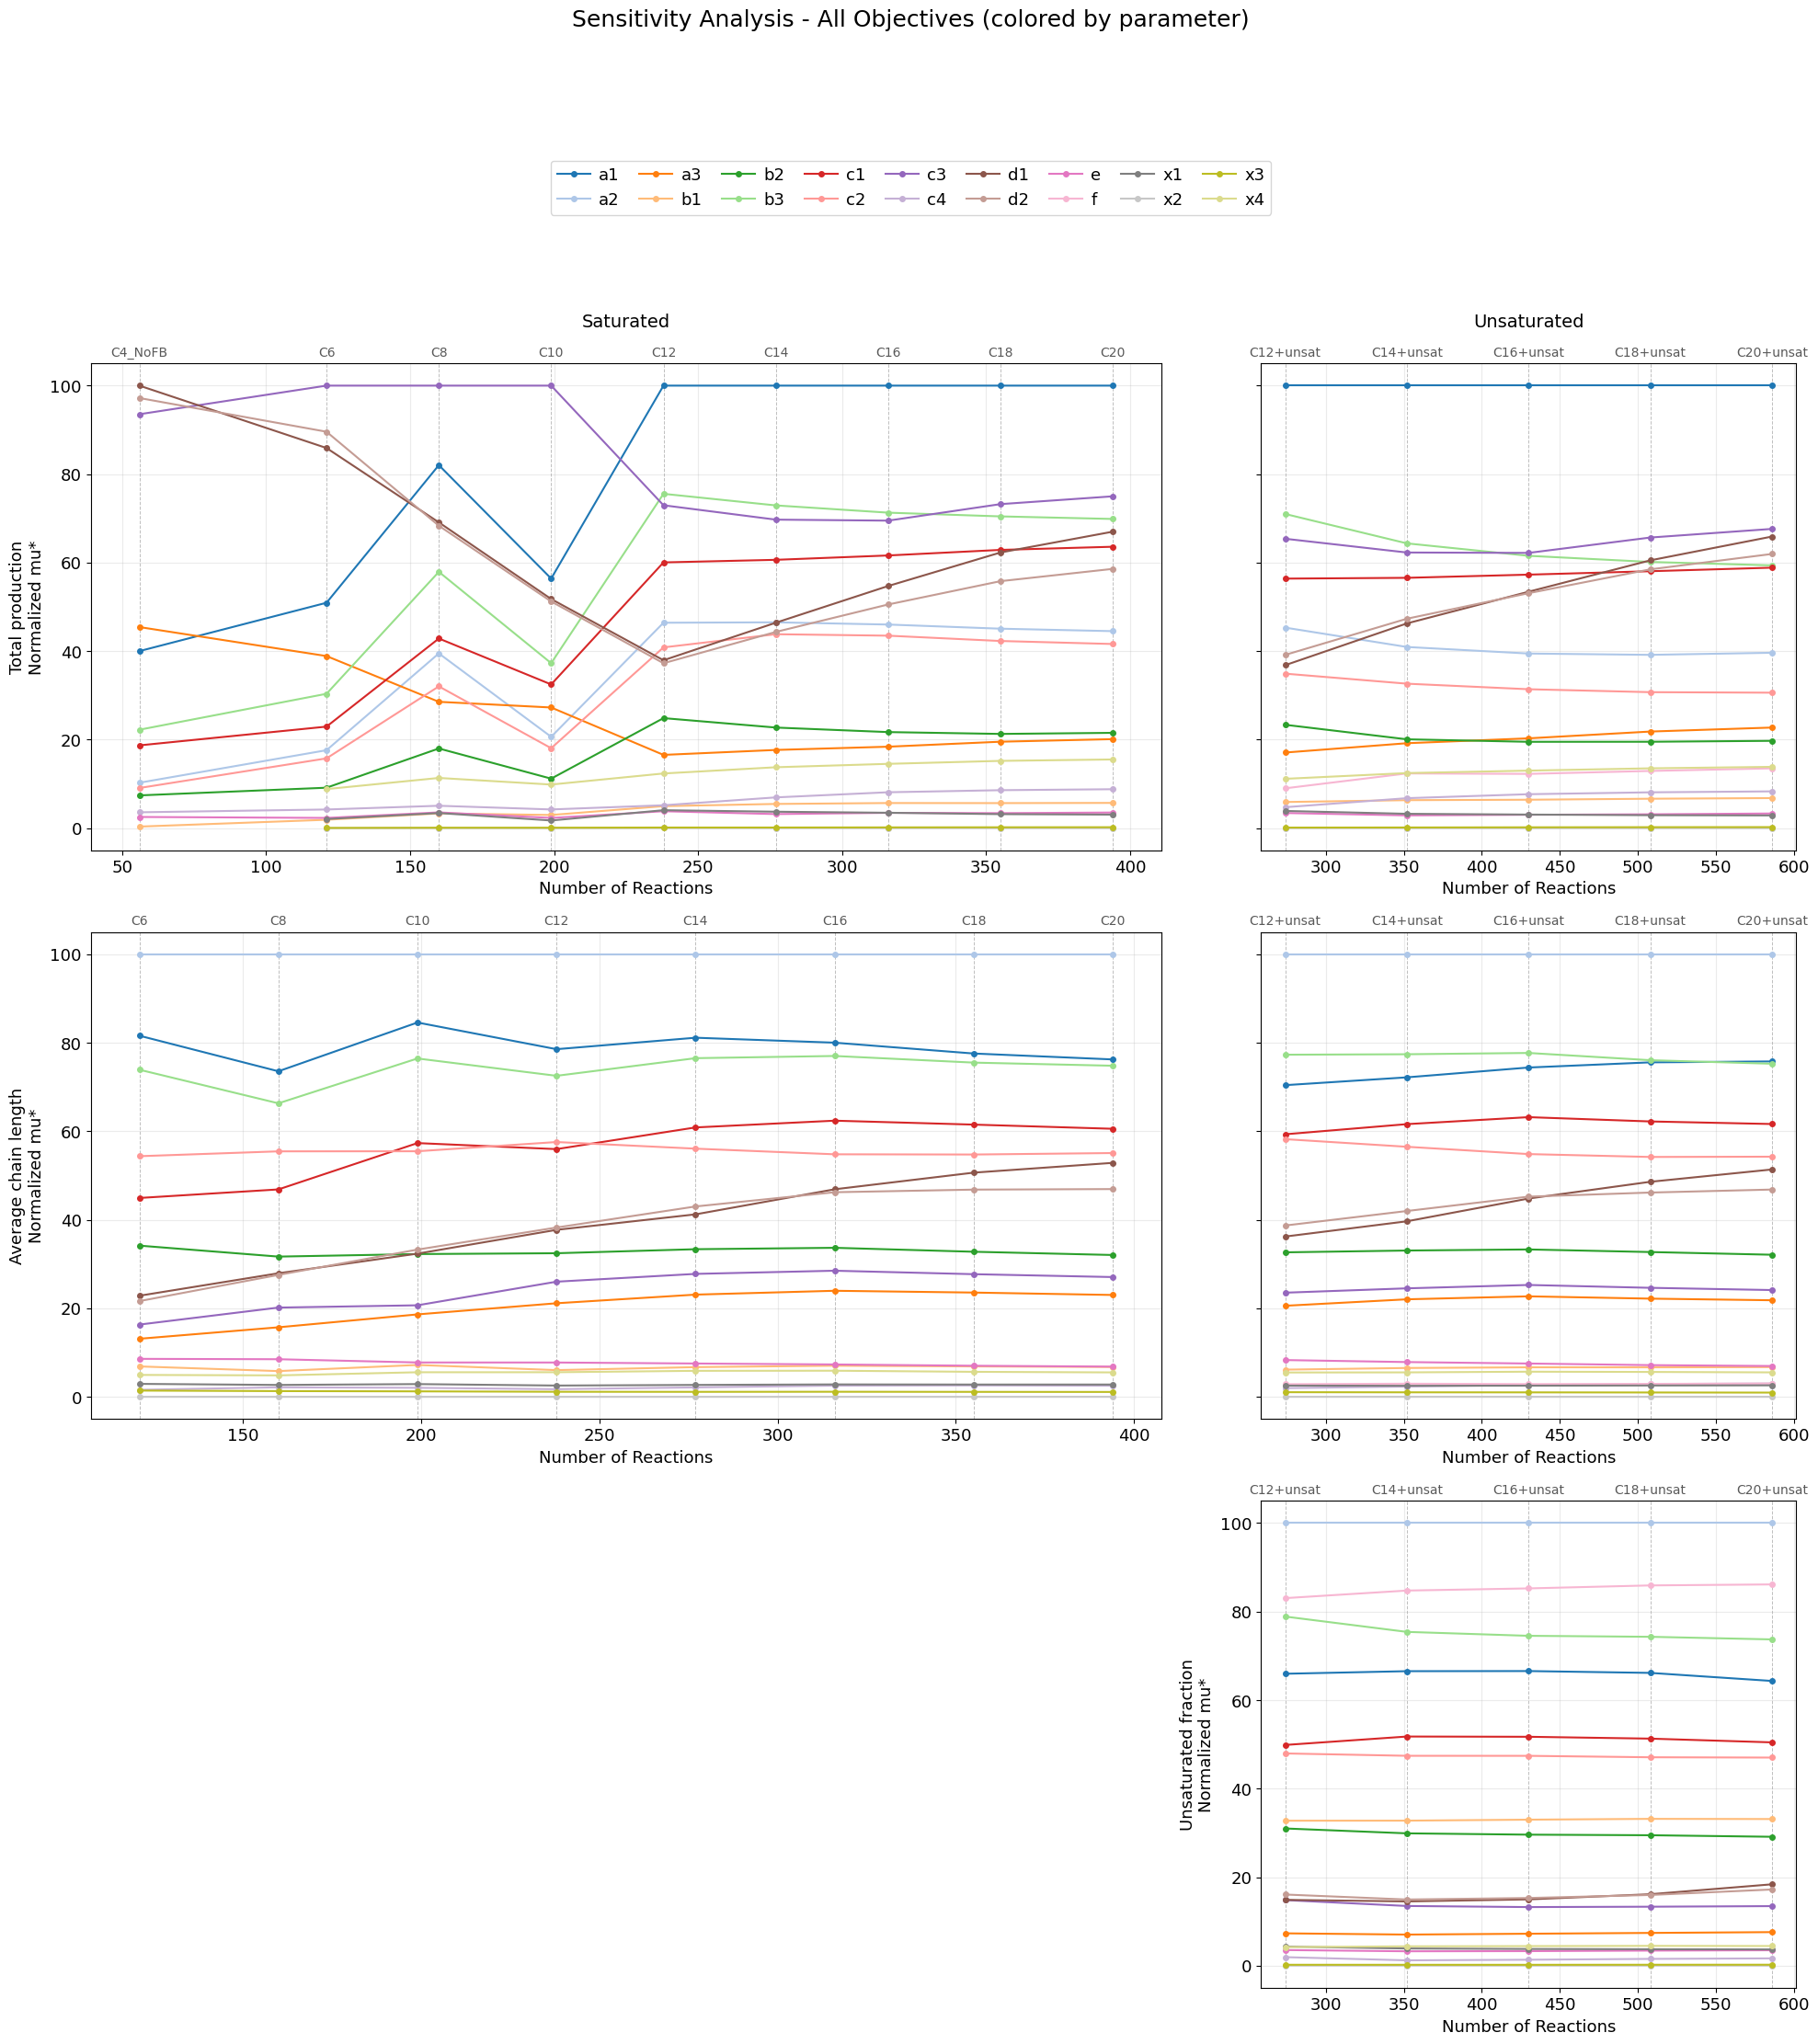

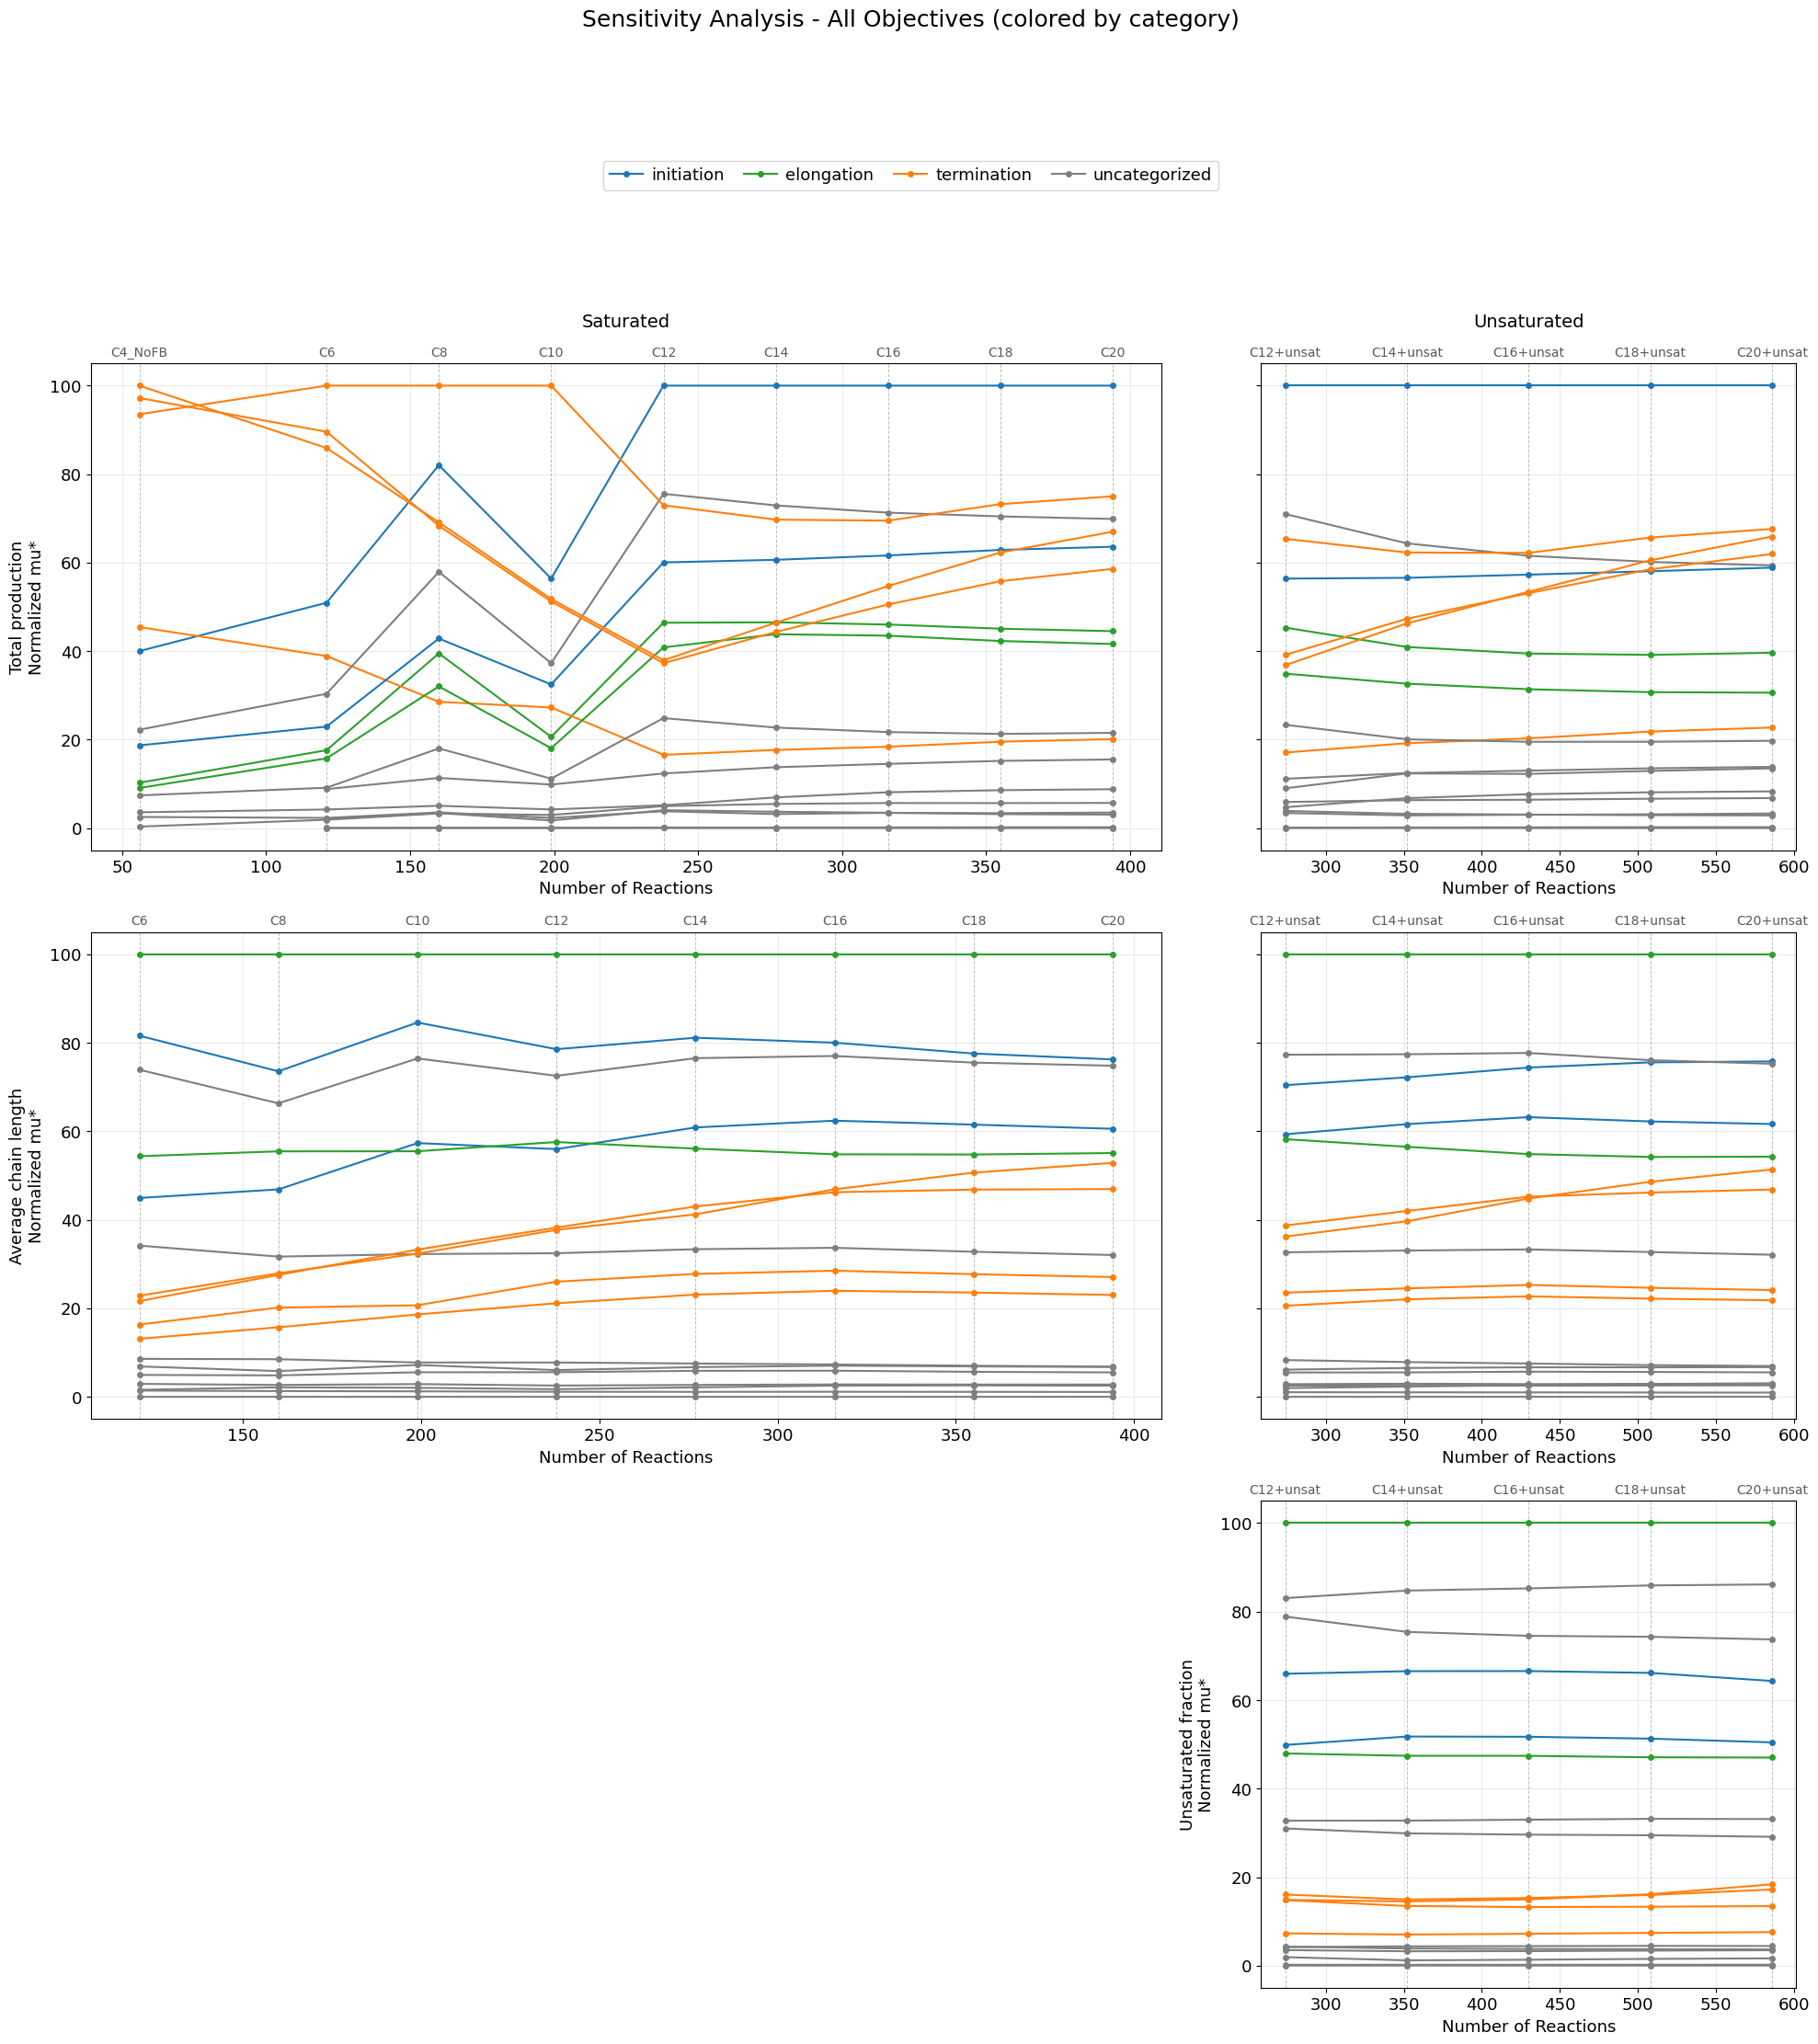

In [6]:
combined_line_trend_figures(MU_STAR)

## Interaction ratio: which groups can't be trusted to a one-at-a-time sweep?

To check whether the mu\* ranking above is safe to interpret independently per
parameter, we measured each group's sigma/mu\* -- already a dimensionless ratio, no
normalization needed. Above ~1, a group's effect depends strongly on where the other
parameters currently sit, meaning a diagonal mass matrix (the sampler's default) will
likely struggle with it in joint inference -- this is exactly what was observed
directly in the a1+c2 pilot (sigma/mu\*=1.77, the sampler's step size never
stabilized) versus a1+c3 (sigma/mu\*=1.55, converged cleanly). Same two views as
above, with a dashed reference line at sigma/mu\*=1.

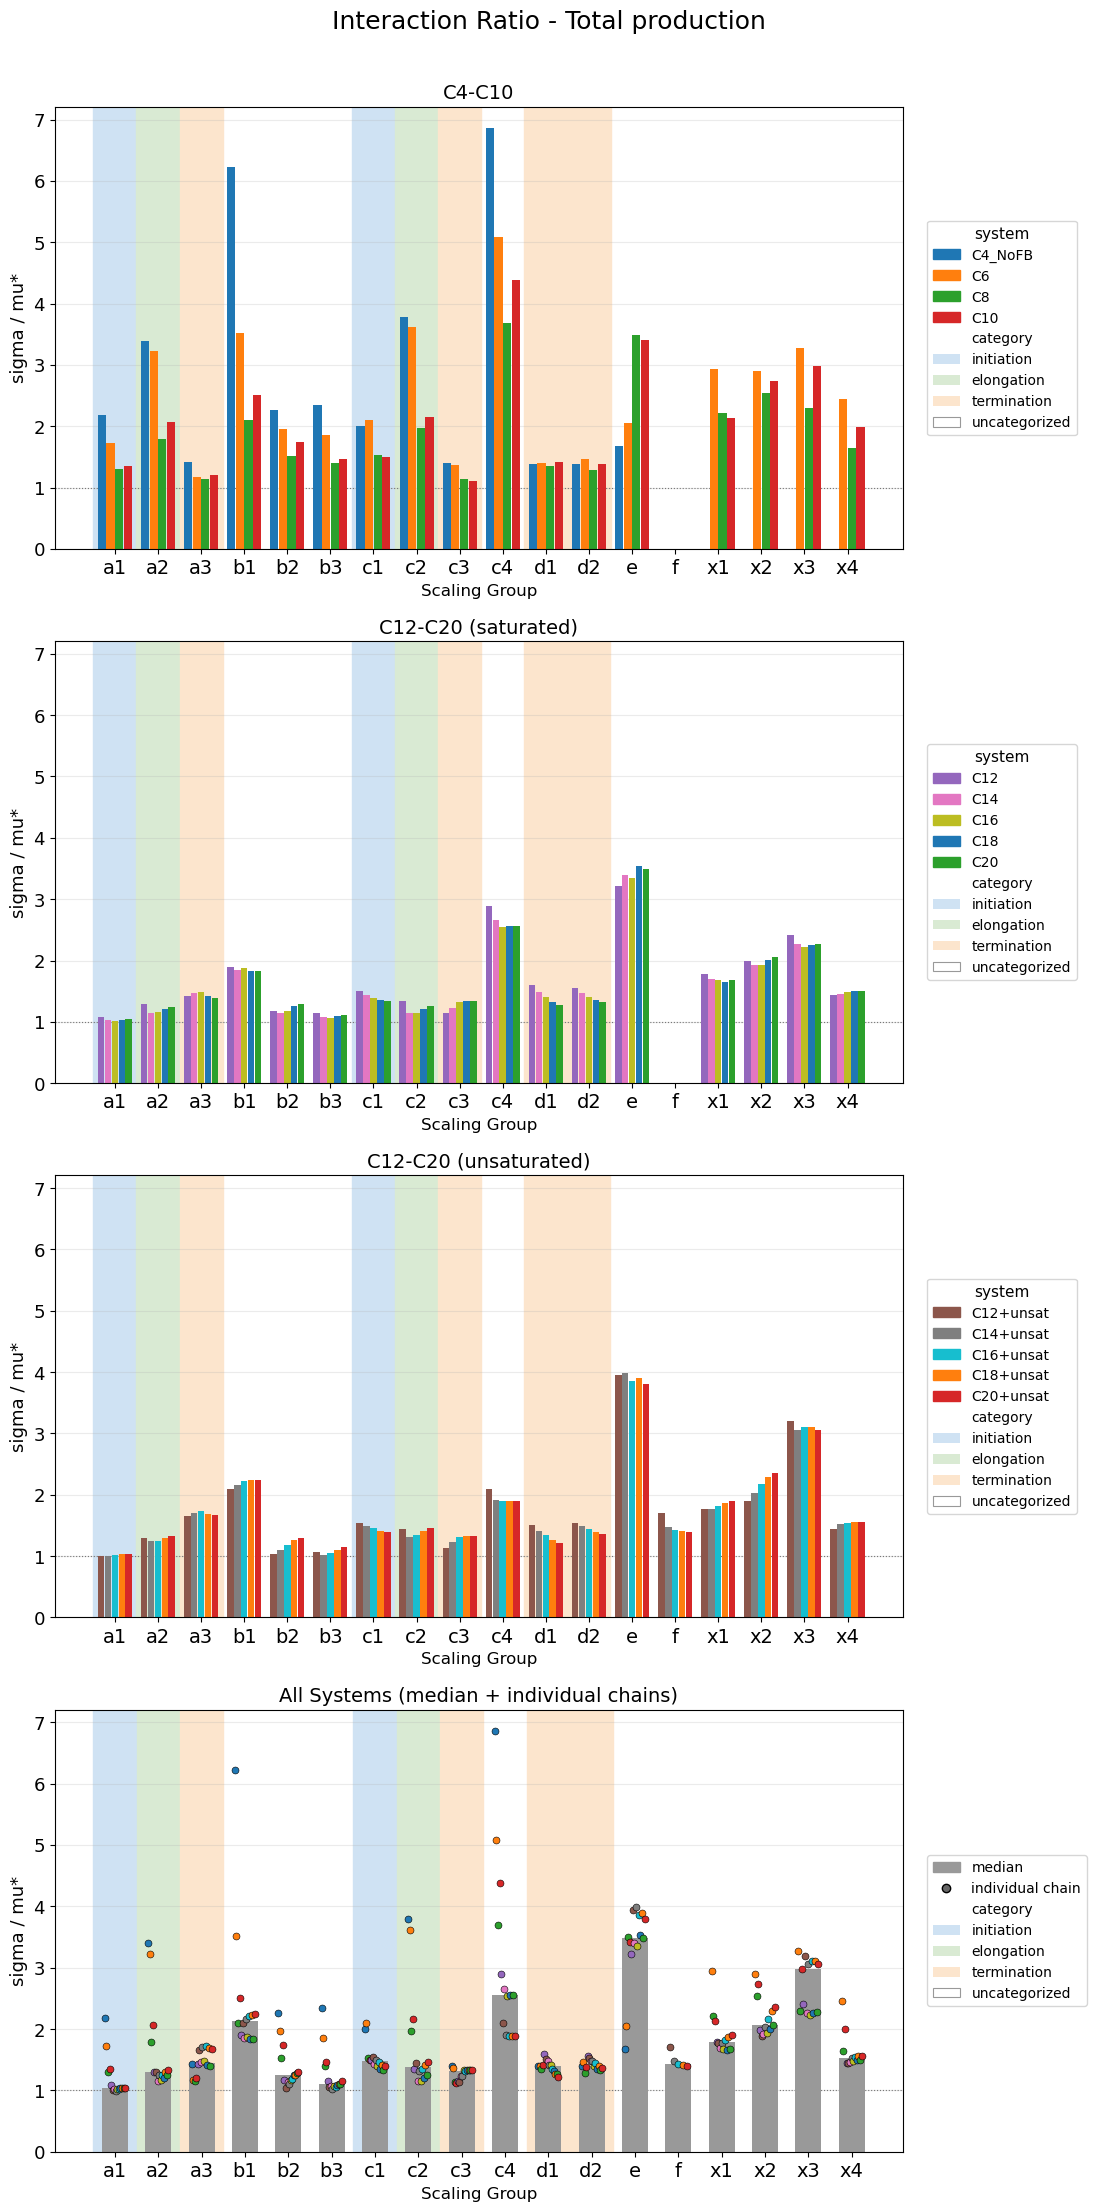

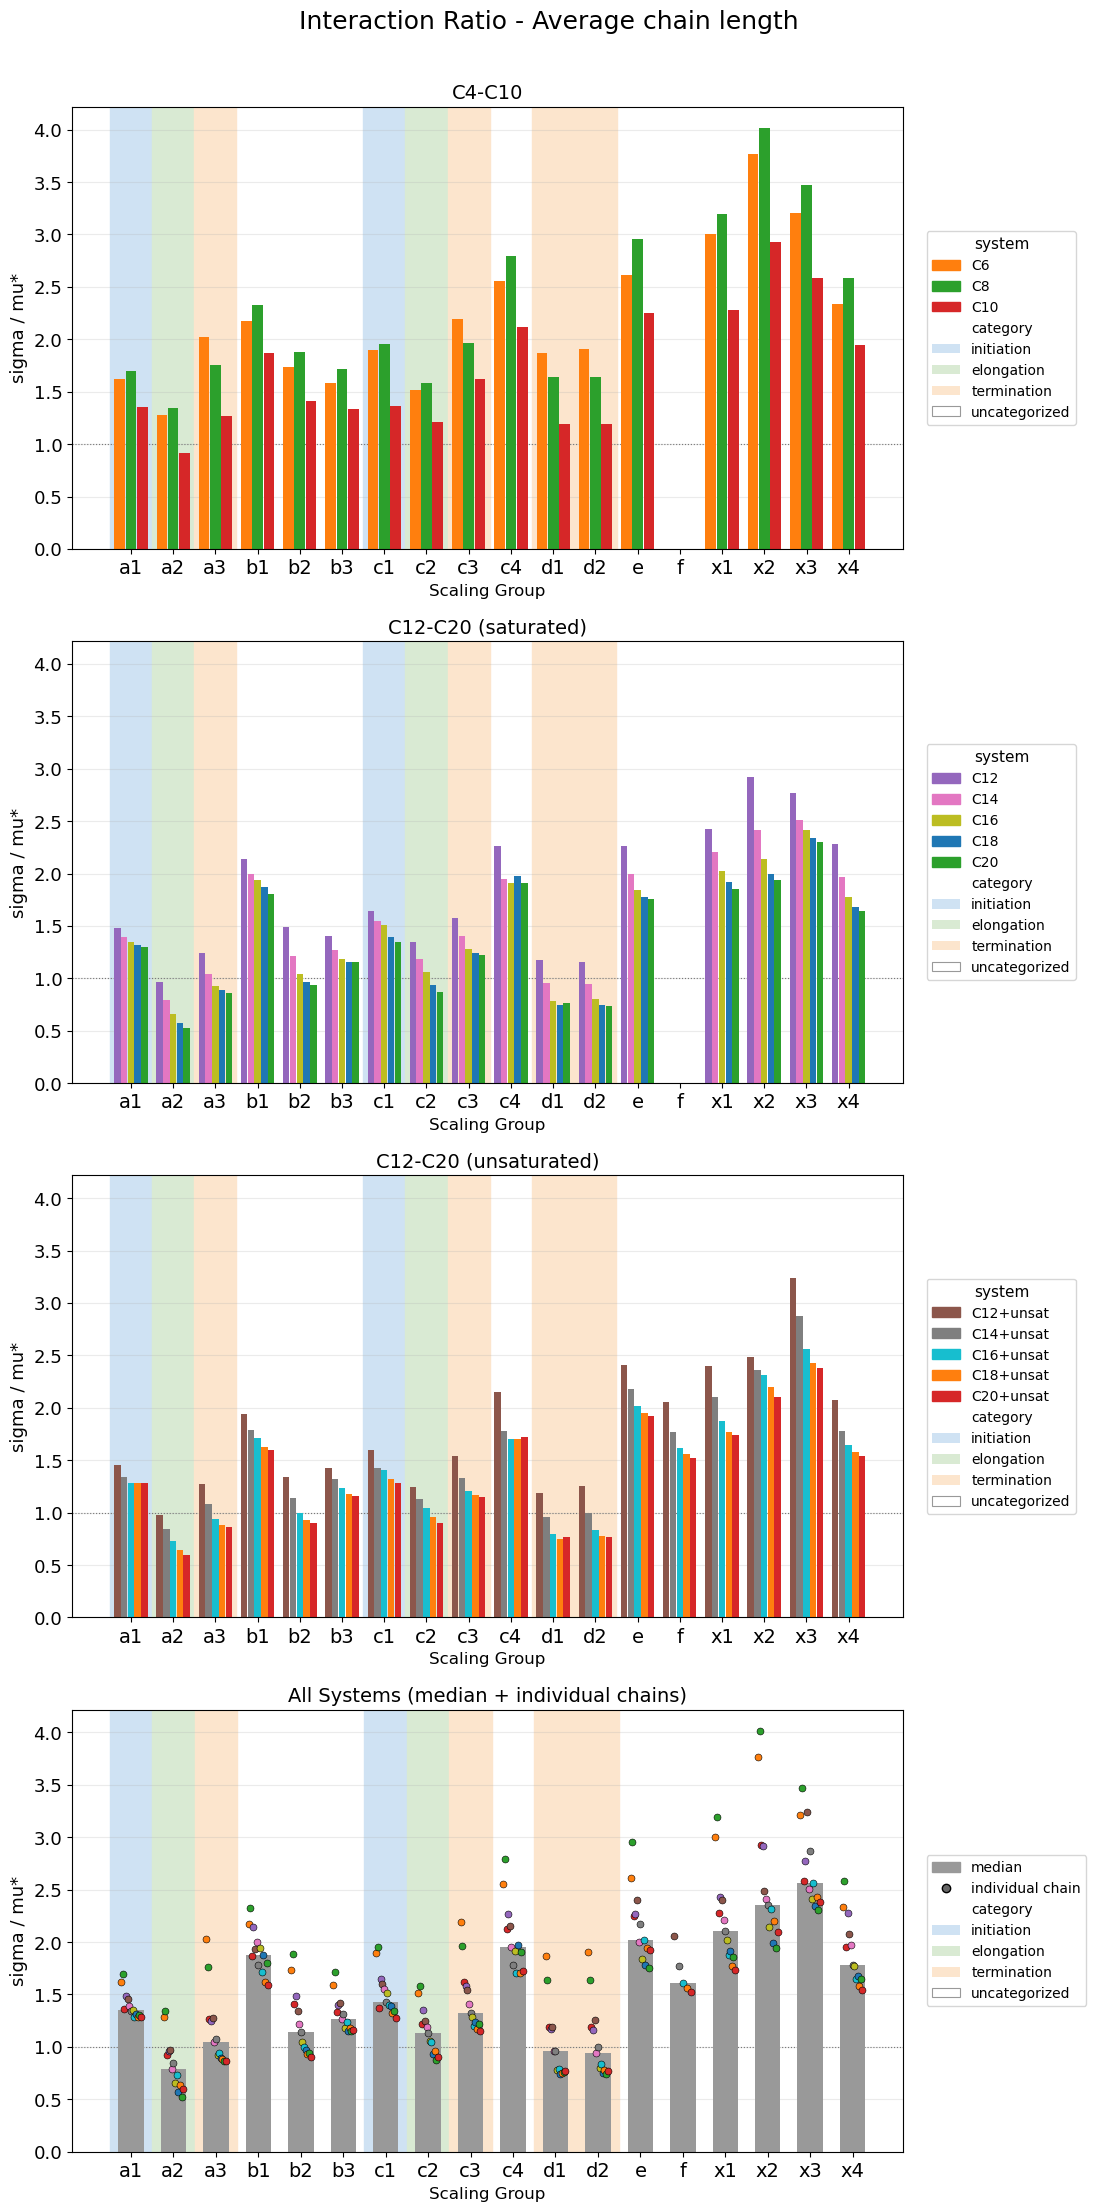

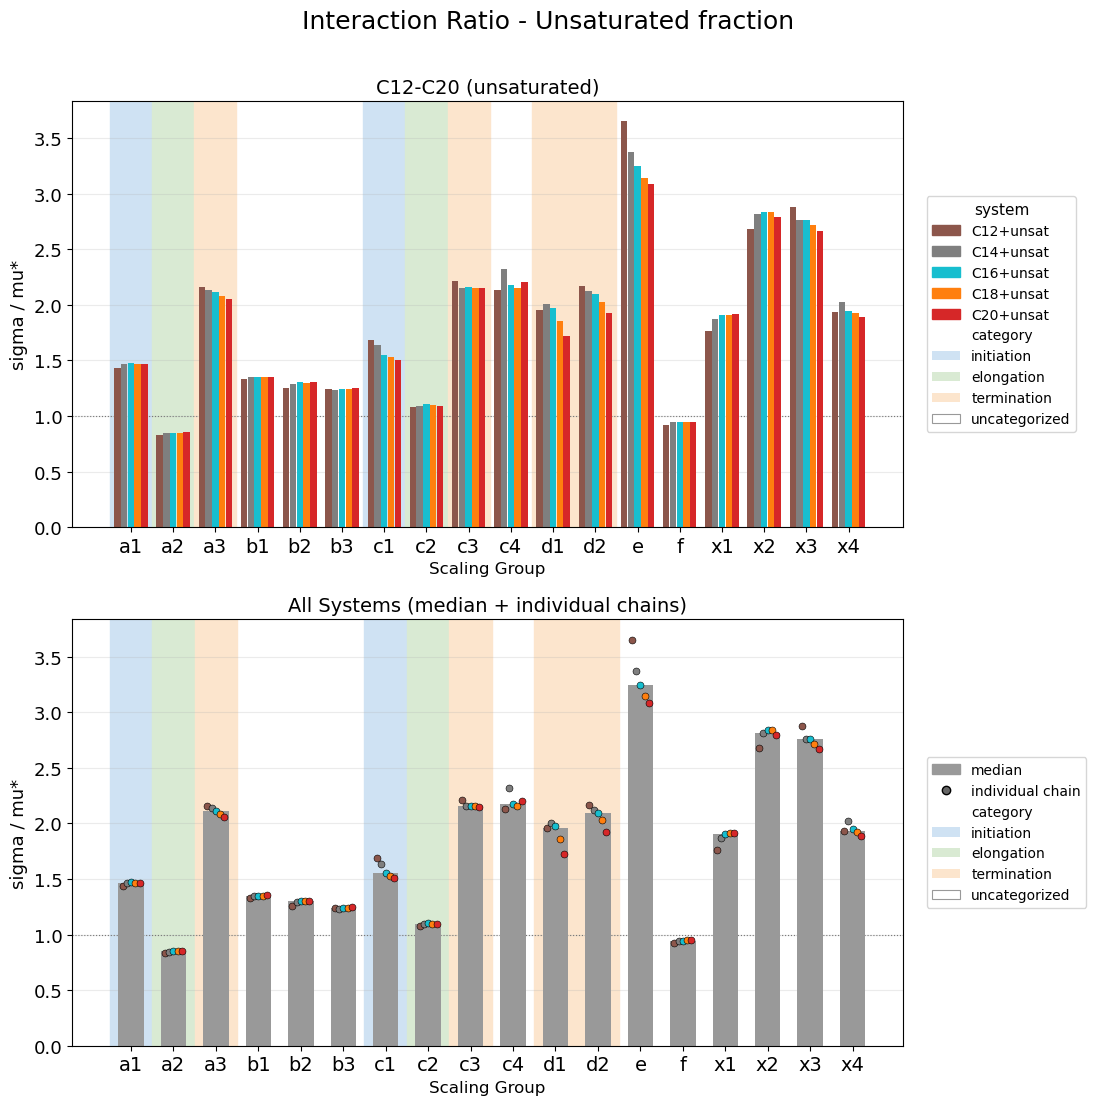

In [7]:
bar_chart_figures(INTERACTION)

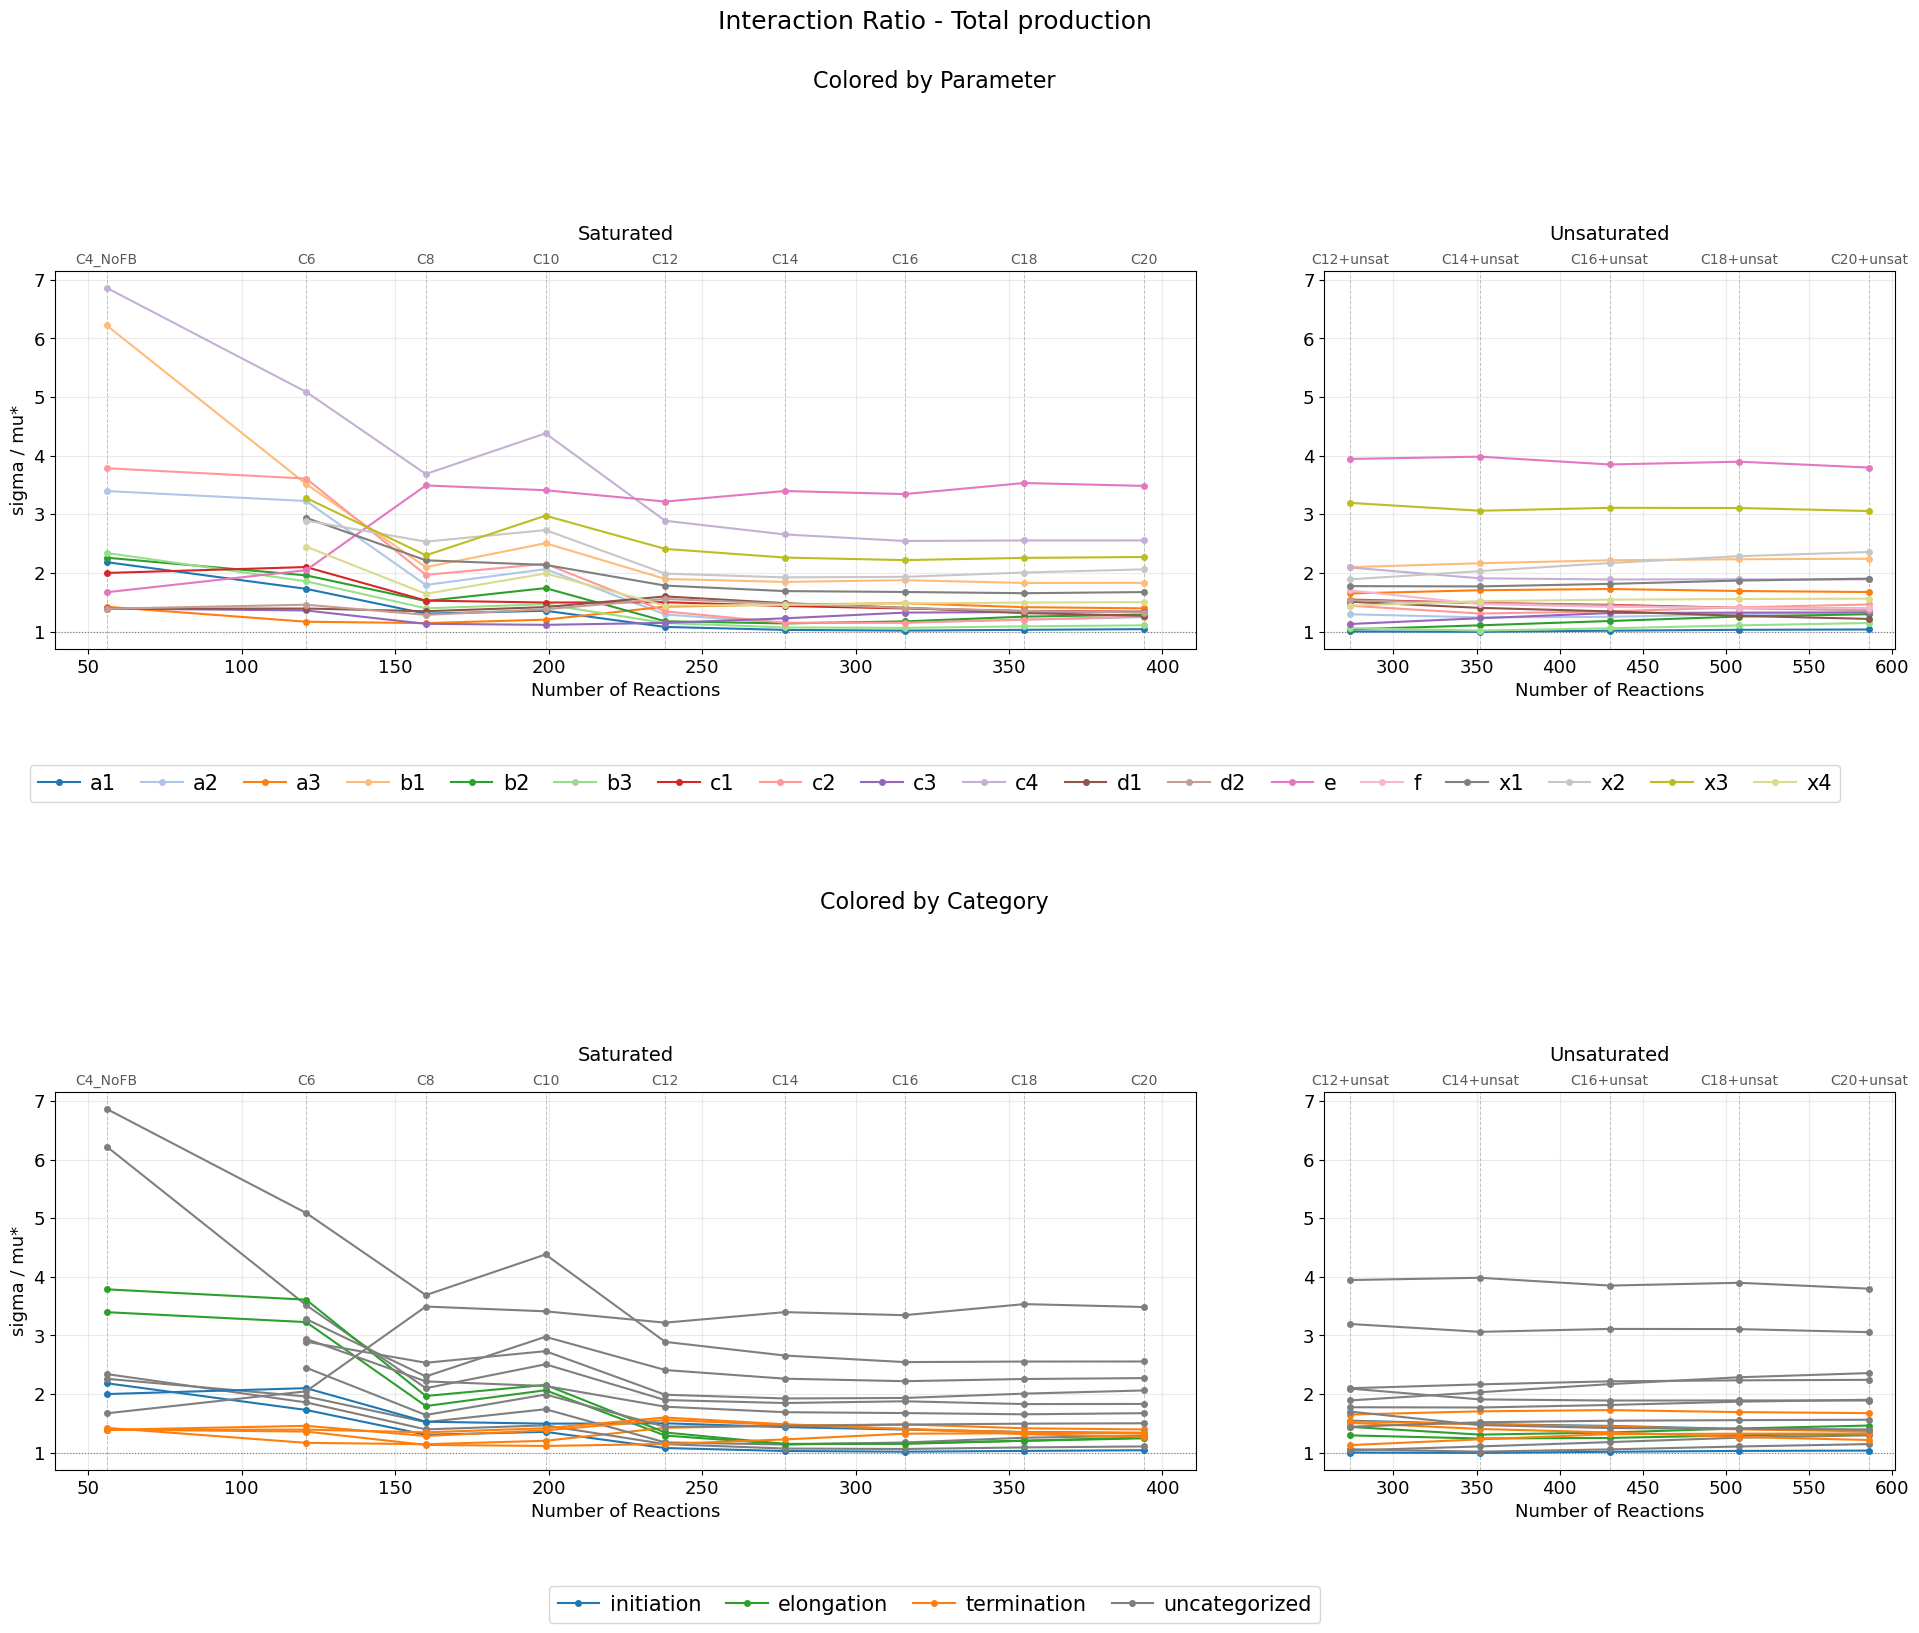

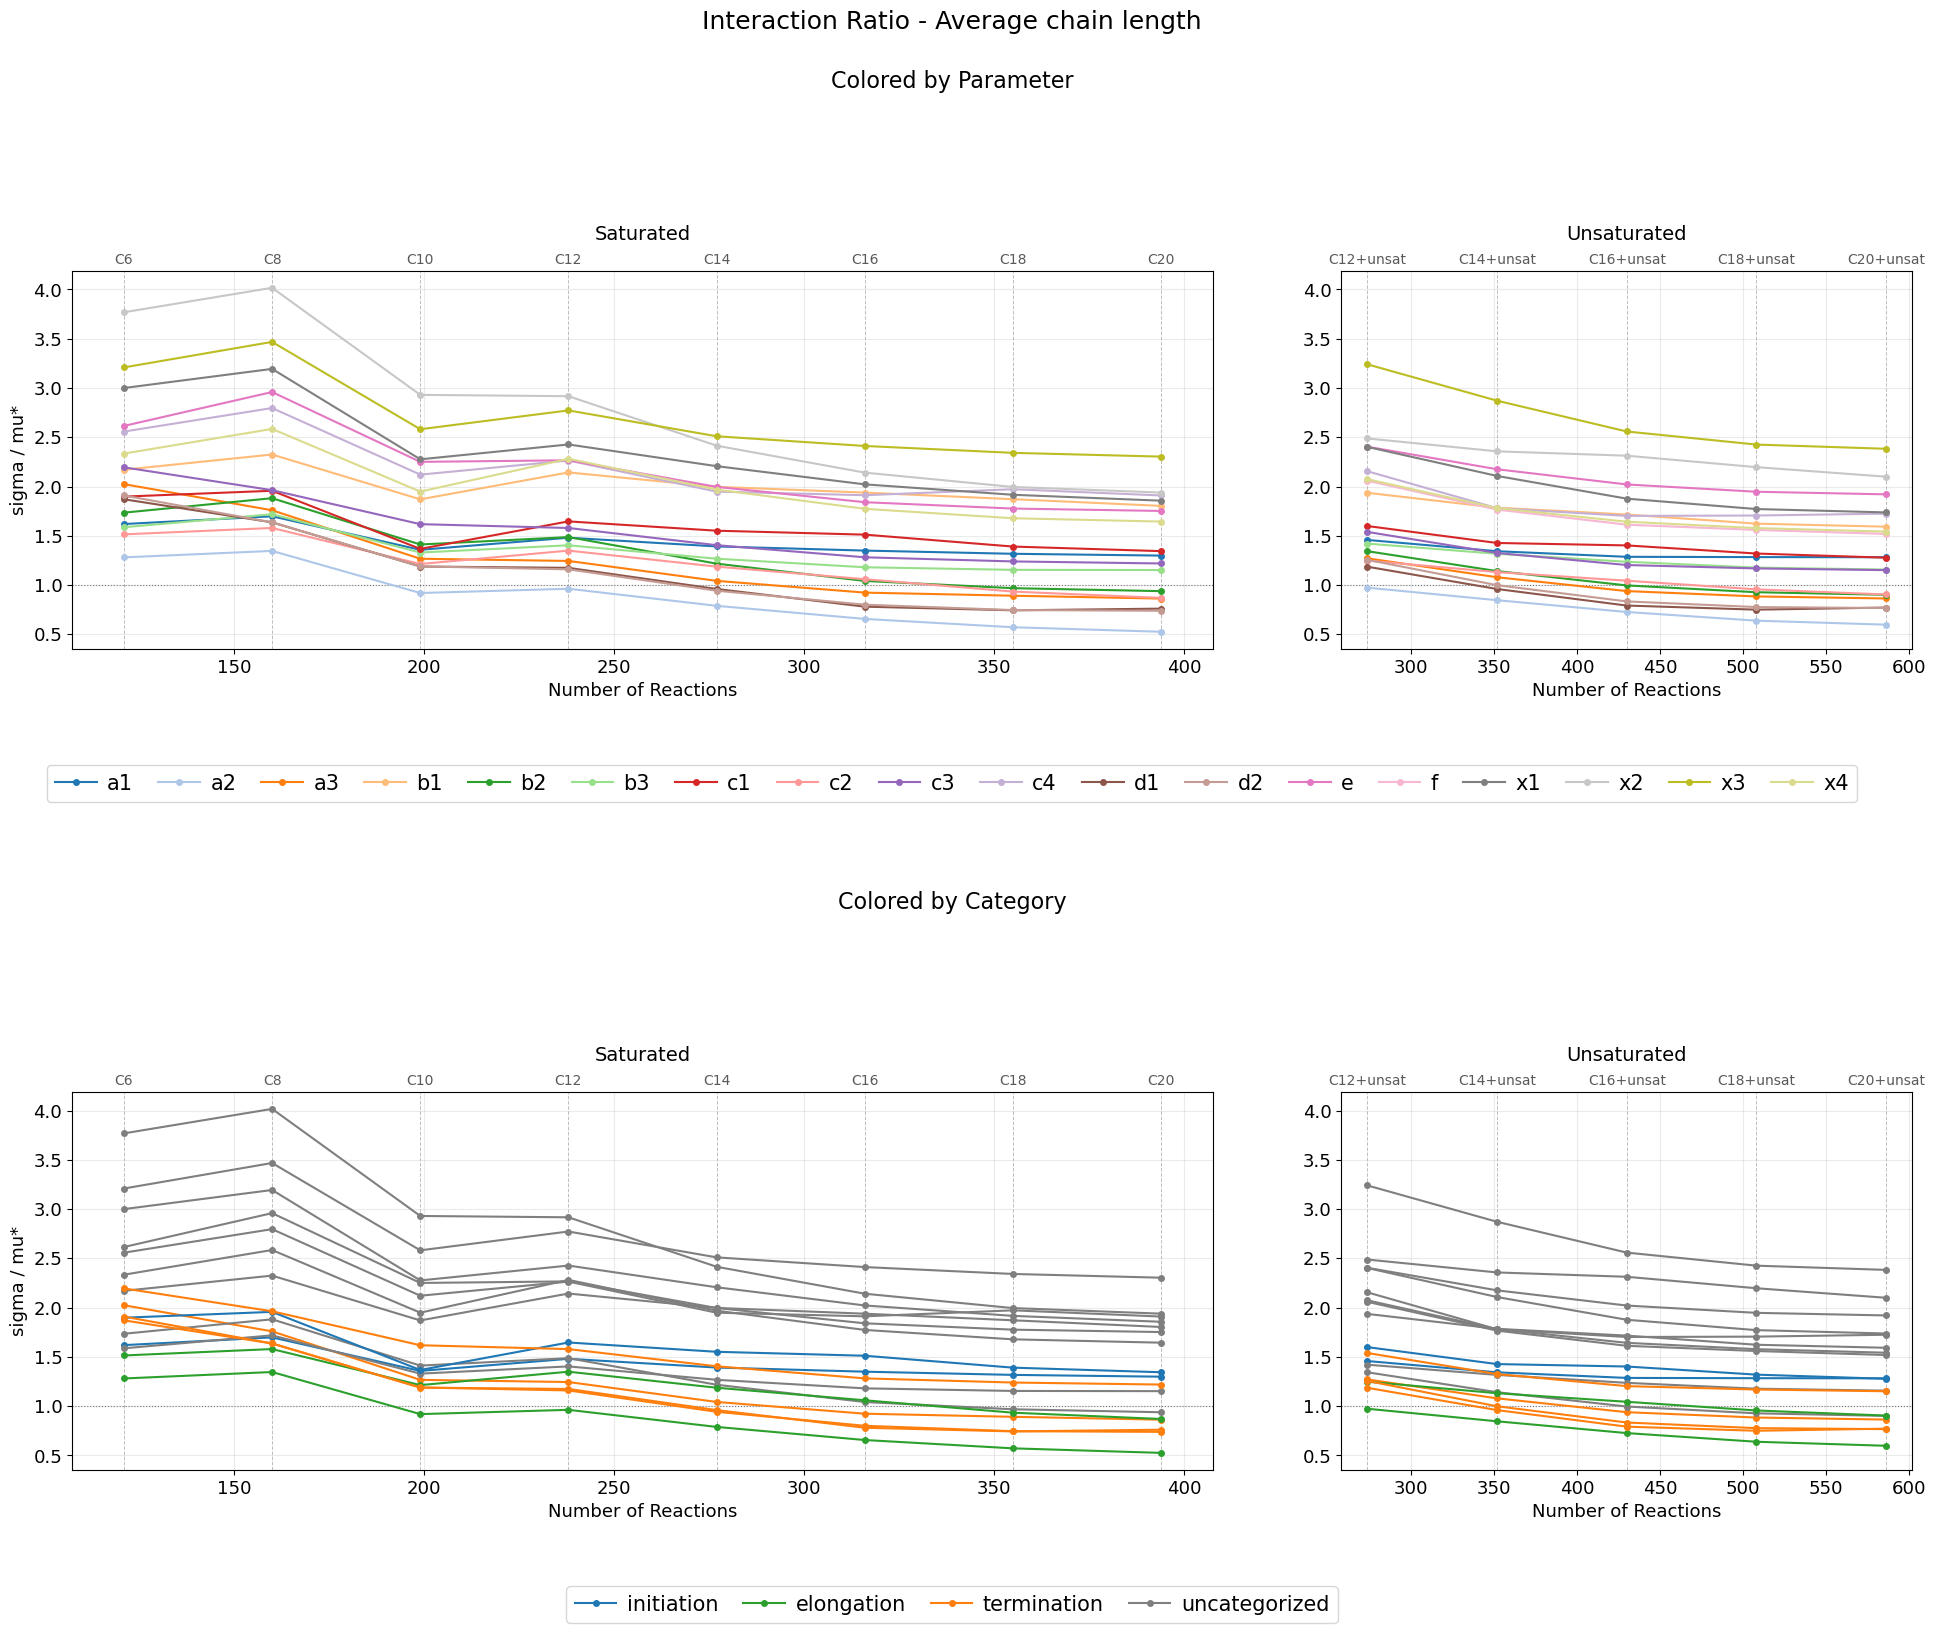

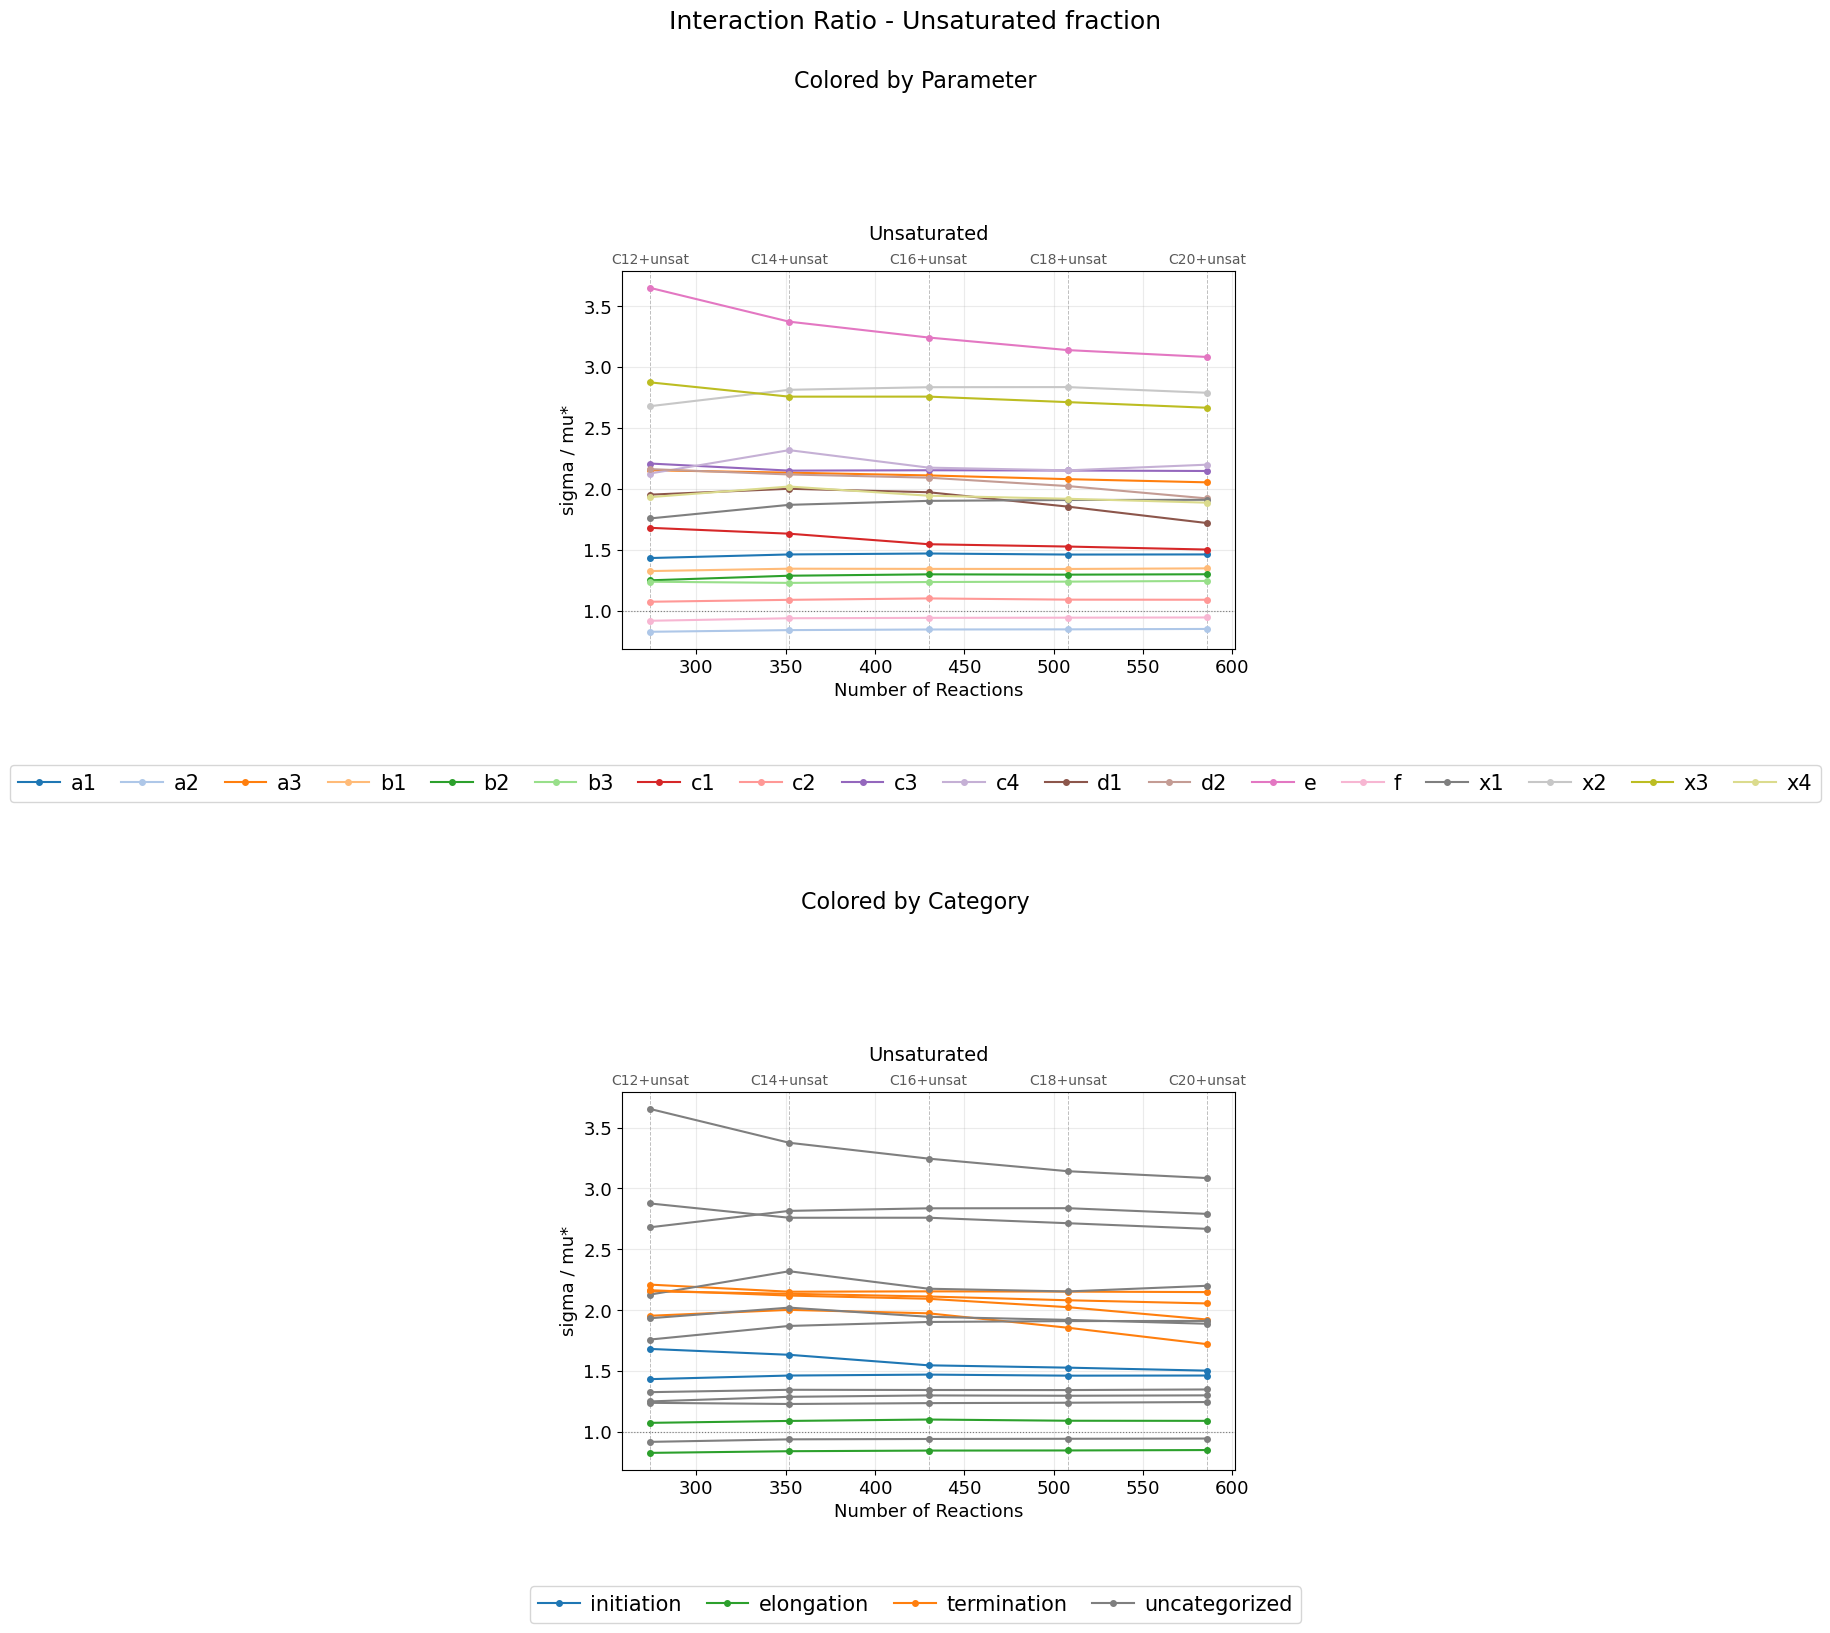

In [8]:
line_trend_figures(INTERACTION)

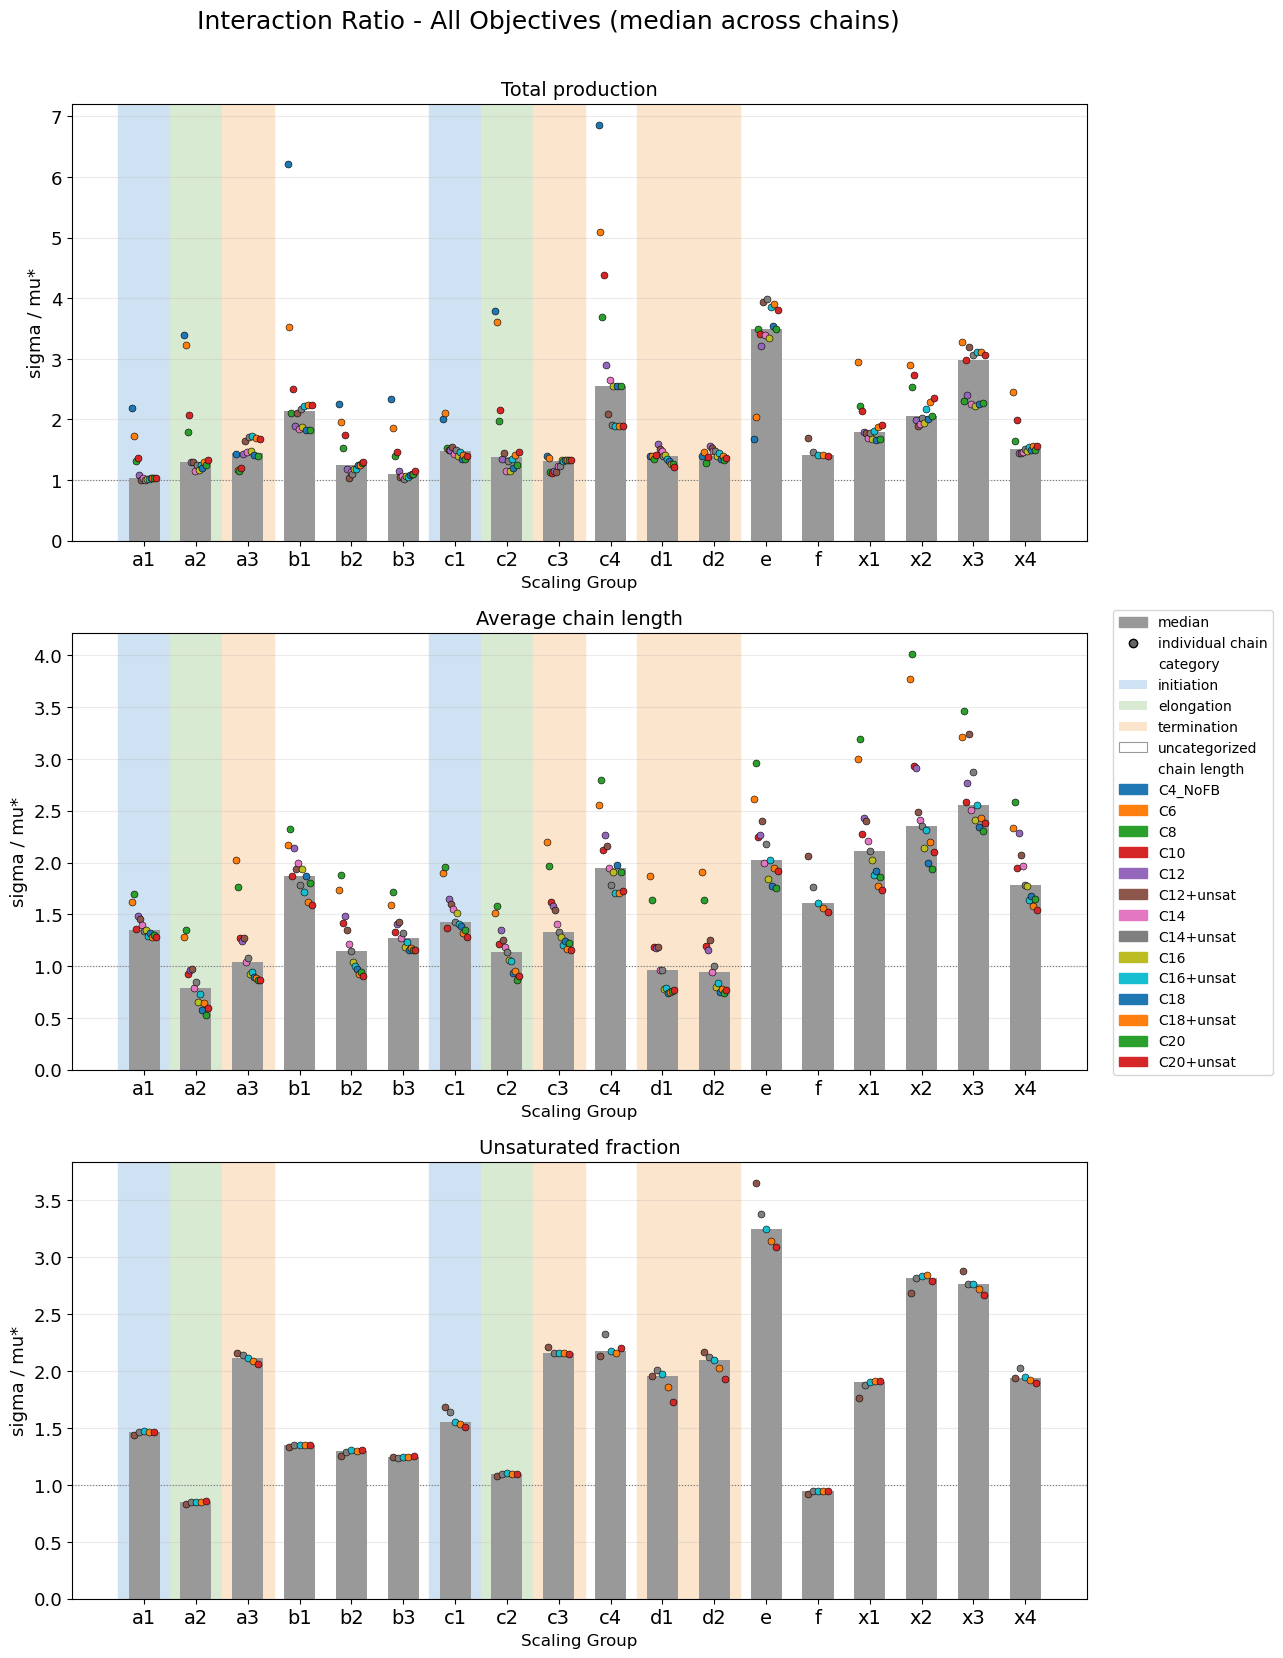

In [9]:
combined_median_figure(INTERACTION)

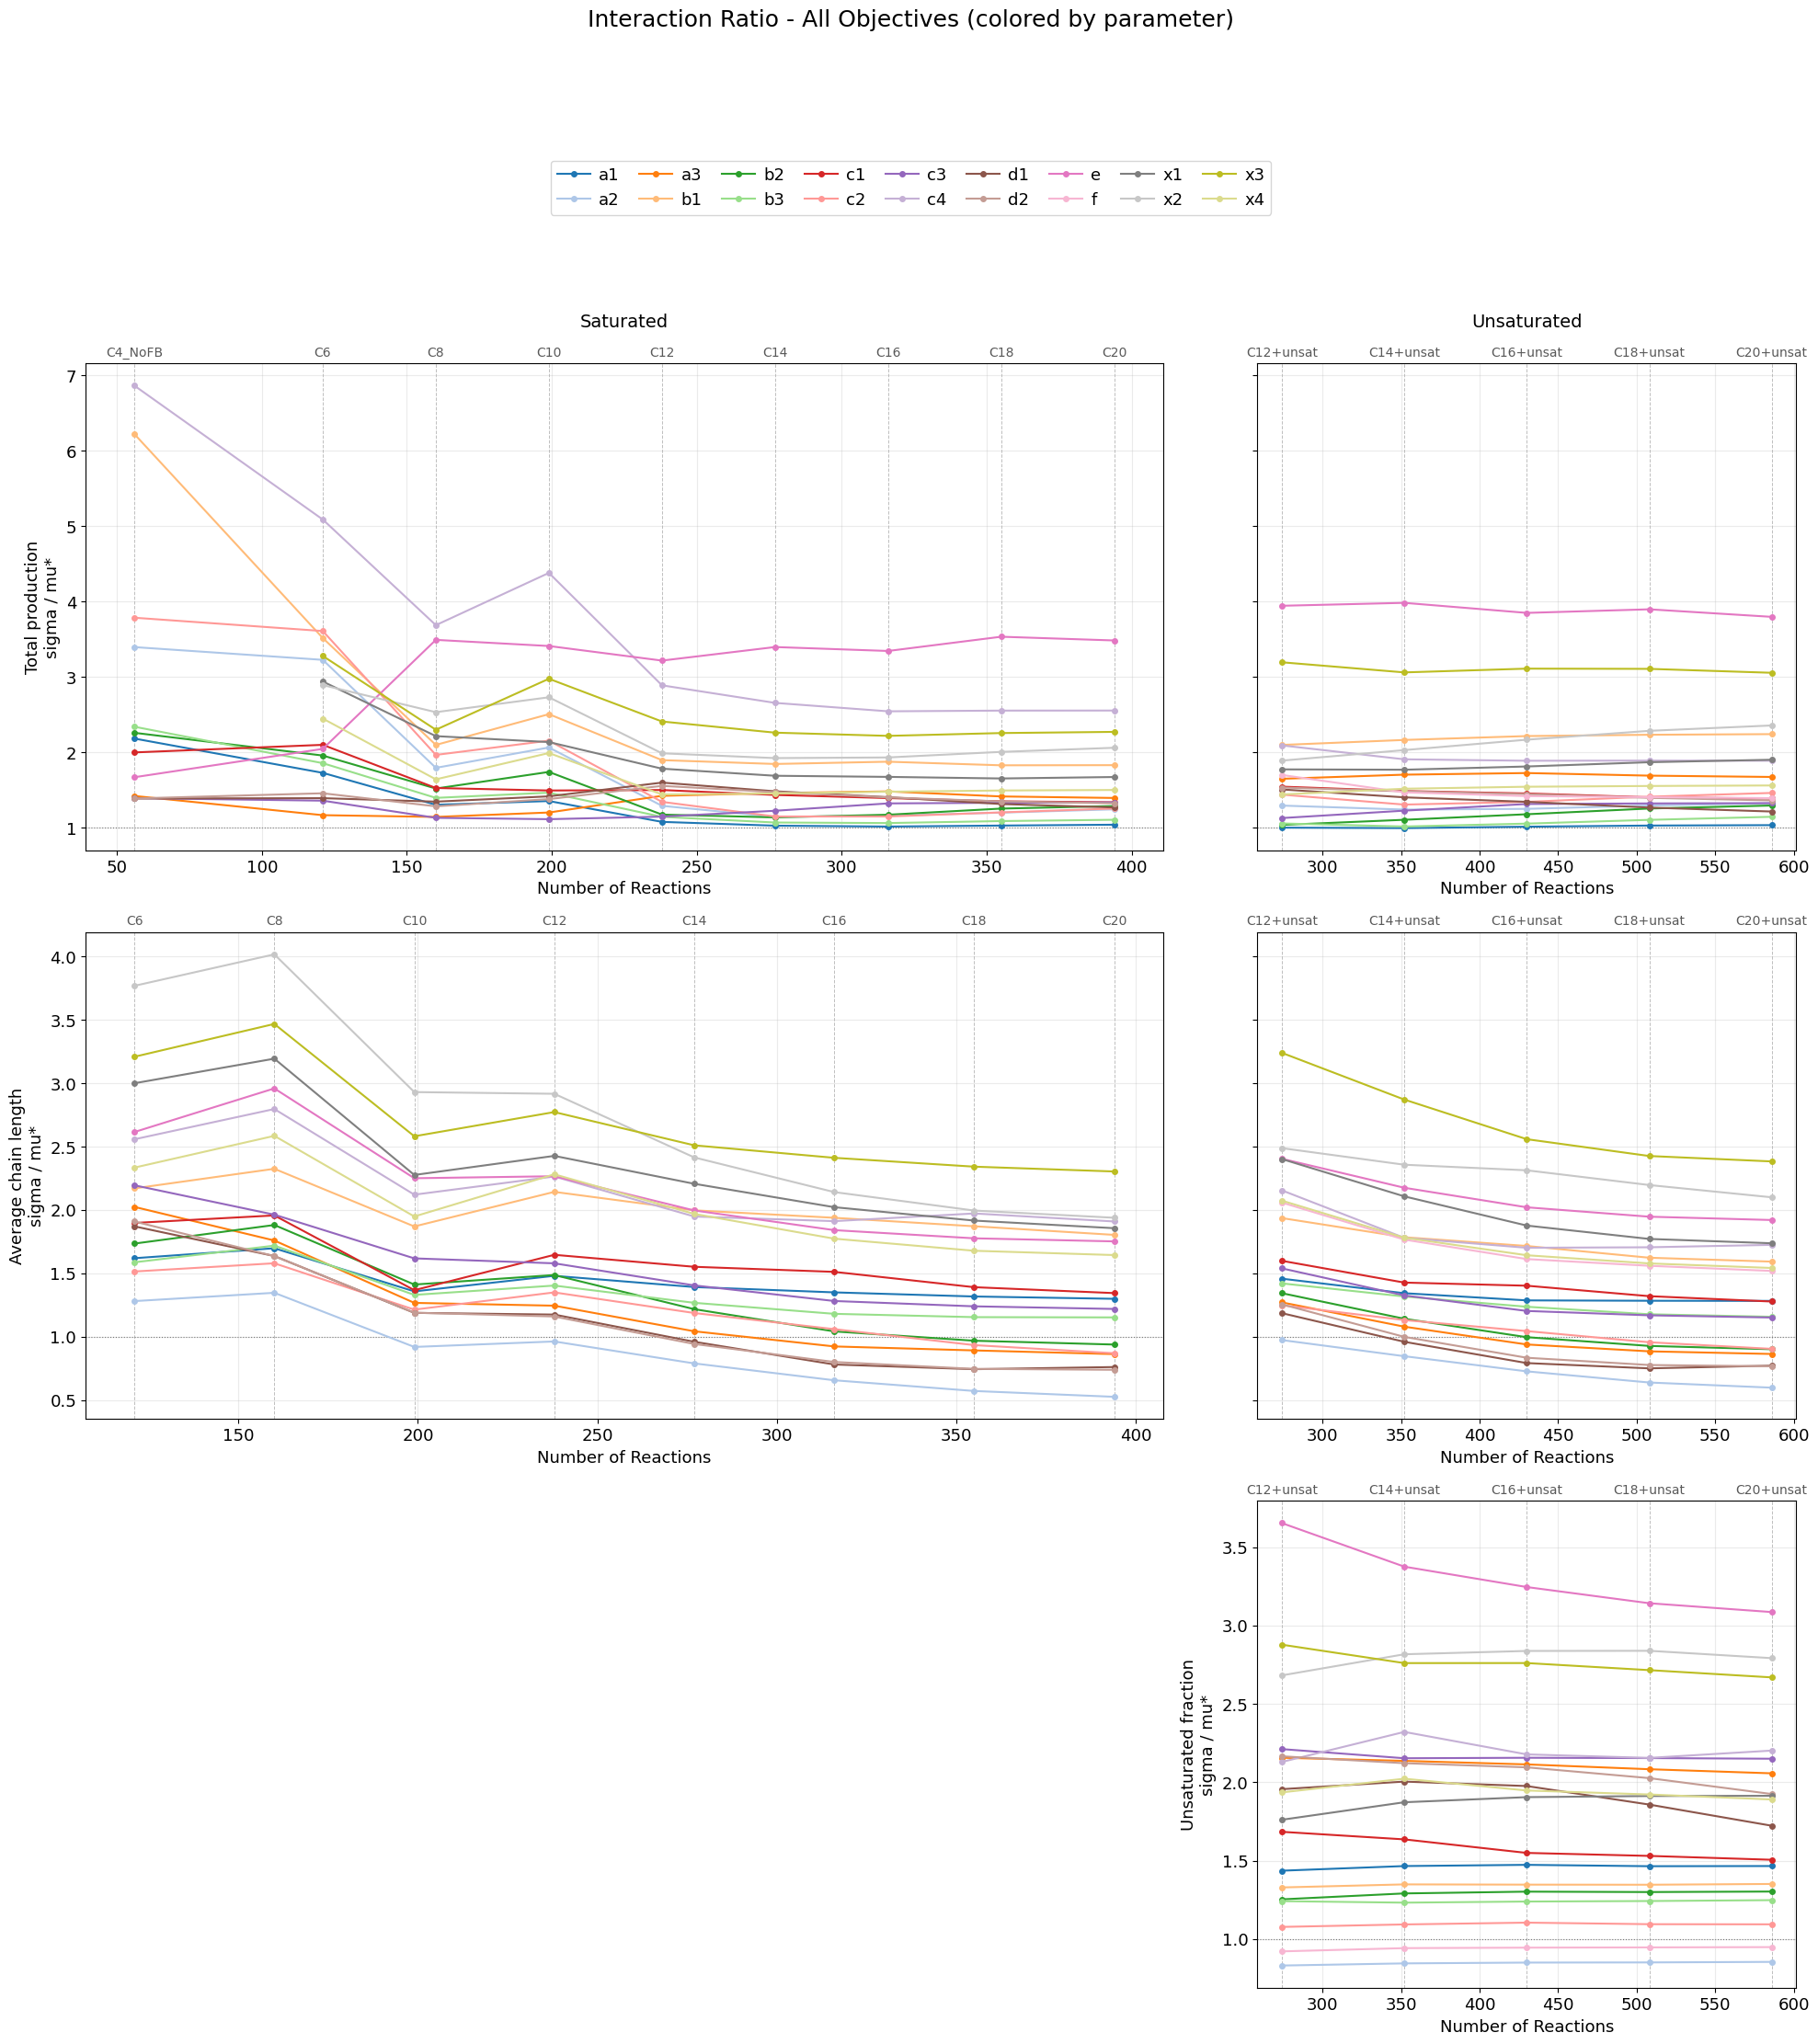

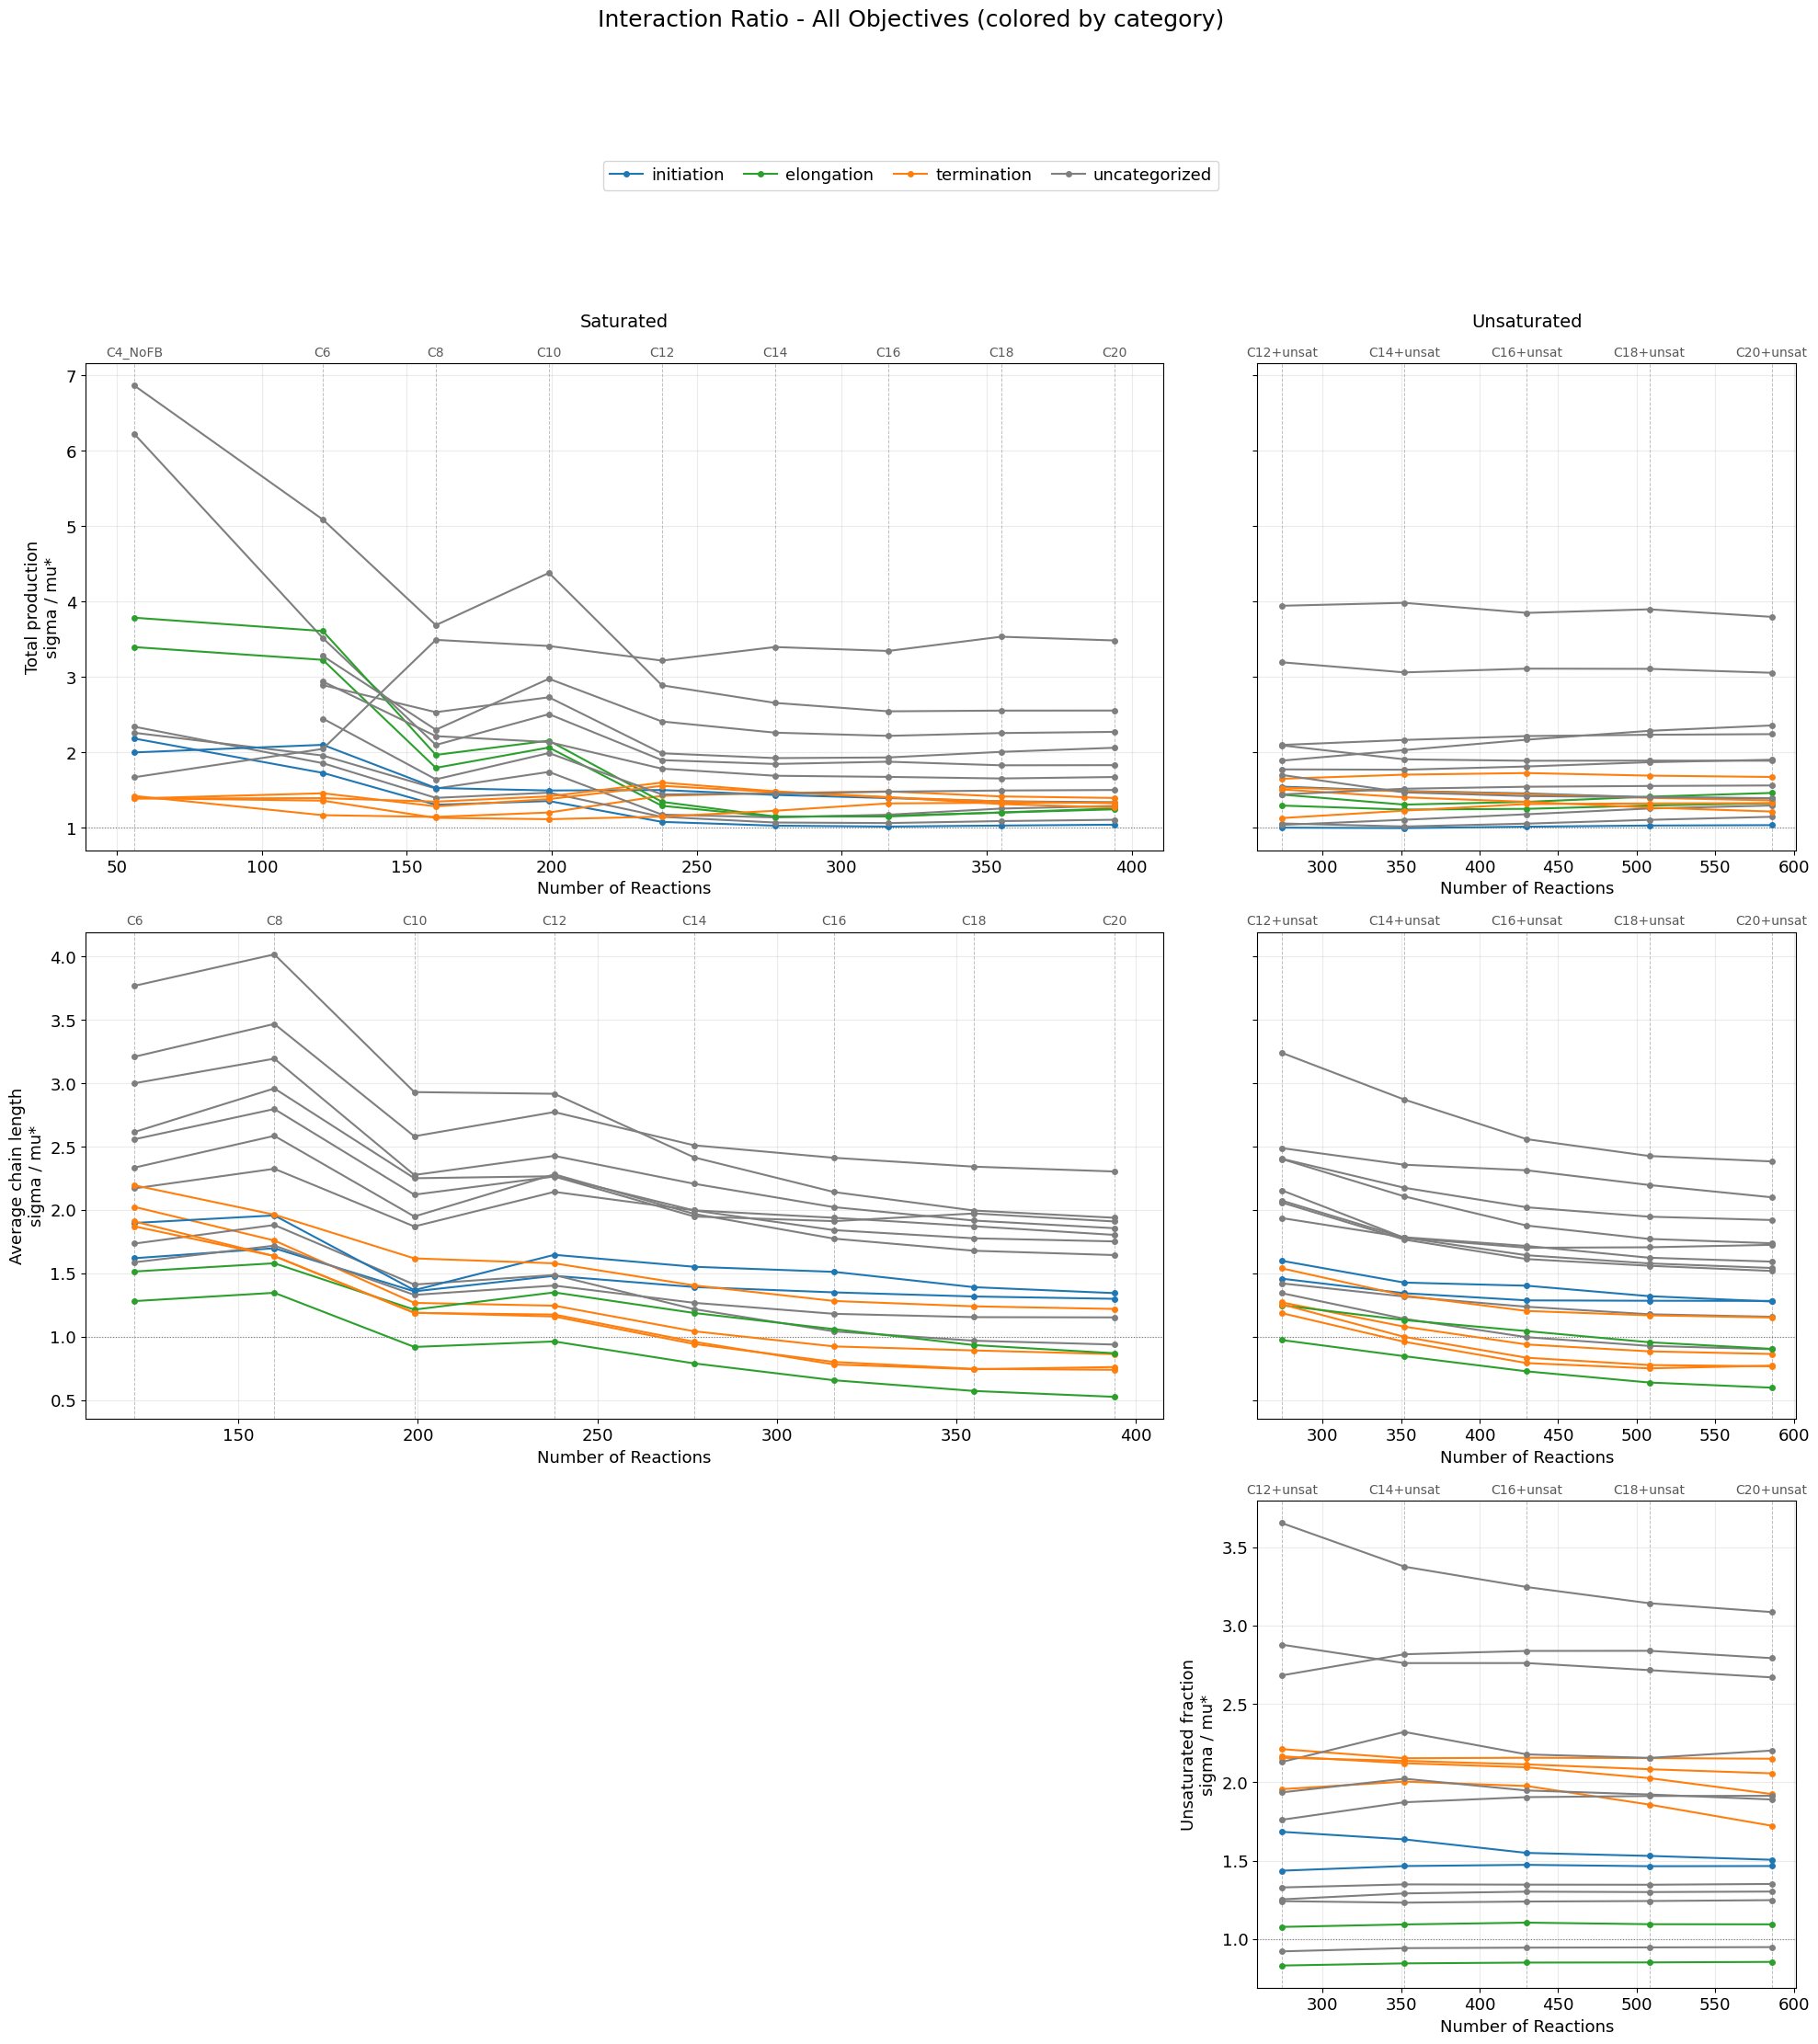

In [10]:
combined_line_trend_figures(INTERACTION)

### Which groups actually need a non-diagonal mass matrix?

The plots above show the full distribution; the table below filters it to the
actionable question -- which groups crossed sigma/mu\*=1 in at least one
(system, objective) pair, and how often. A group that never crosses it can keep
being screened one-at-a-time with a diagonal mass matrix; one that crosses it
often is a candidate to pair cautiously (as `a1`+`c2` turned out to be) or with
a denser mass matrix.

In [11]:
rows = []
for g in ALL_GROUPS:
    crossings, worst = 0, 0.0
    for obj in OBJECTIVES:
        per_group = INTERACTION.table(obj)
        for val in per_group.get(g, {}).values():
            if val > INTERACTION.threshold:
                crossings += 1
            worst = max(worst, val)
    rows.append({"group": g, "category": GROUP_STAGE.get(g, "uncategorized"),
                "n_crossings (sigma/mu*>1)": crossings, "worst sigma/mu*": round(worst, 2)})
df_interaction = pd.DataFrame(rows).sort_values("n_crossings (sigma/mu*>1)", ascending=False).reset_index(drop=True)
df_interaction

,group,category,n_crossings (sigma/mu*>1),worst sigma/mu*
0,b3,uncategorized,32,2.34
1,b1,uncategorized,32,6.22
2,c4,uncategorized,32,6.86
3,e,uncategorized,32,3.98
4,c3,termination,32,2.21
5,c1,initiation,32,2.10
6,x4,uncategorized,31,2.58
7,a1,initiation,31,2.18
8,x3,uncategorized,31,3.47
9,x2,uncategorized,31,4.02
